In [2]:
# import xarray as xr
# import numpy as np
# import pandas as pd
# import xesmf as xe
# import intake
# # import psyplot.project as psy
# import matplotlib.pyplot as plt
# import matplotlib.path as mpath
# import matplotlib.colors as mcolors

# import cartopy.crs as ccrs
# import gsw
# import sys
# import os
# import cmocean.cm as cm
# sys.path.append('/g/data/jk72/zc0441')
# from zpackage import wmt
# from zpackage.zclef_v2 import *

## Ztake

In [1]:
from __future__ import annotations
from typing import Any, Dict, Iterable, List, Optional, Tuple
from dataclasses import dataclass, field
import pandas as pd
import numpy as np
import xarray as xr
import intake


@dataclass
class Ztake:
    cmip6_catalog: Any                     # intake-ESM catalog (top-level)
    constraints: Dict[str, Any]
    chunks: Dict[str, int] = field(default_factory=lambda: {"time": 12})
    prefer_members: Tuple[str, ...] = ("r1i1p1f1","r1i1p1f2","r1i1p1f3")
    prefer_grids:   Tuple[str, ...] = ("gn","gr","gr1","gr2")

    # internals
    sid: Any = field(init=False, repr=False)
    _df: pd.DataFrame = field(init=False, repr=False)
    _best_df: pd.DataFrame = field(init=False, repr=False)

    def __post_init__(self):
        cons = dict(self.constraints)
        if "variable" in cons and "variable_id" not in cons:
            cons["variable_id"] = cons.pop("variable")
        self.sid = self.cmip6_catalog.search(**cons)
        self._df = self.sid.df.copy()
        
        # ensure a 'path' column exists
        if "path" not in self._df.columns:
            self._df["path"] = self._df.get("uri", pd.Series(np.arange(len(self._df)), index=self._df.index)).astype(str)

        # parse version and rank preferences
        v = self._df["version"].astype(str).str.lstrip("v")
        self._df["version_num"] = pd.to_numeric(v, errors="coerce").fillna(0).astype(int)
        self._df["member_rank"] = self._rank_by_pref(self._df["member_id"], self.prefer_members)
        self._df["grid_rank"]   = self._rank_by_pref(self._df["grid_label"], self.prefer_grids)

        # pick best row per (model, variable)
        self._best_df = (
            self._df.groupby(["source_id","variable_id"], group_keys=False)
                    .apply(self._pick_best_one)
                    .reset_index(drop=True)
        )
        # build model list once (from best_df)
        self._model_list = sorted(self._best_df["source_id"].unique().tolist())
        
    # ---------- helpers ----------
    @staticmethod
    def _rank_by_pref(s: pd.Series, prefs: Tuple[str, ...]) -> pd.Series:
        m = {v: i for i, v in enumerate(prefs)}
        return s.map(m).fillna(len(prefs)+100).astype(int)

    @staticmethod
    def _pick_best_one(g: pd.DataFrame) -> pd.DataFrame:
        return (g.sort_values(
                    by=["member_rank","grid_rank","version_num","path"],
                    ascending=[True, True, False, True],
                    kind="mergesort")
                .head(1))

    def _paths_for_choice(self, row: pd.Series) -> List[str]:
        """
        From the full filtered DF, collect *all files* that match the chosen
        model/variable + member/grid/version (so we get the full time series).
        """
        mask = (
            (self._df["source_id"]   == row["source_id"])  &
            (self._df["variable_id"] == row["variable_id"])&
            (self._df["member_id"]   == row["member_id"])  &
            (self._df["grid_label"]  == row["grid_label"]) &
            (self._df["version"]     == row["version"])
        )
        paths = self._df.loc[mask, "path"].astype(str).tolist()
        # stable order helps open_mfdataset find time in order
        paths.sort()
        if not paths:
            raise FileNotFoundError(f"No files for {row['source_id']} {row['variable_id']} {row['member_id']} {row['grid_label']} v{row['version']}")
        return paths

    # ---------- public API ----------
    @property
    def df(self) -> pd.DataFrame:
        return self._df.copy()

    @property
    def best_per_model_variable(self) -> pd.DataFrame:
        cols = ["source_id","variable_id","member_id","grid_label","version","version_num","path"]
        return self._best_df.loc[:, [c for c in cols if c in self._best_df.columns]].copy()

    def models(self) -> List[str]:
        return sorted(self._best_df["source_id"].unique())

    def variables_for(self, model: str) -> List[str]:
        return sorted(self._best_df.query("source_id == @model")["variable_id"].unique())

    def info(self) -> pd.DataFrame:
        df = self._best_df
        return (df.groupby("source_id", as_index=False)
                  .agg(n_vars=("variable_id","nunique"),
                       members=("member_id", lambda x: ",".join(sorted(pd.unique(x)))),
                       grids=("grid_label", lambda x: ",".join(sorted(pd.unique(x)))),
                       newest_version=("version_num","max"))
                  .sort_values("source_id")
                  .reset_index(drop=True))

    def open(
        self,
        variables: Optional[Iterable[str]] = None,
        time_range: Optional[Tuple[str, str]] = None,
        engine: Optional[str] = None,                 # e.g., "netcdf4" on Gadi
        decode_times: bool = True,
        drop_conflicts: bool = True,
    ) -> Dict[str, xr.Dataset]:
        """
        Open using file PATHS from the dataframe (no to_dataset_dict).
        - Concatenate files of each variable with open_mfdataset(by_coords)
        - Merge variables per model with xr.merge
        """
        sel = self._best_df
        if variables is not None:
            variables = tuple(variables)
            sel = sel[sel["variable_id"].isin(variables)]
            if sel.empty:
                raise ValueError(f"No rows match requested variables: {variables}")

        out: Dict[str, xr.Dataset] = {}
        for model, g in sel.groupby("source_id"):
            var_ds: List[xr.Dataset] = []

            for _, row in g.iterrows():
                paths = self._paths_for_choice(row)

                # If there are known “meta” vars that cause conflicts, you can drop them in preprocess
                def _pre(ds):
                    # keep only target variable + its coords to be safe
                    keep = [row["variable_id"]]
                    # try to keep coordinates present
                    keep += [c for c in ("time","lat","latitude","lon","longitude","x","y") if c in ds.variables]
                    return ds[sorted(set(v for v in keep if v in ds.variables))]

                ds = xr.open_mfdataset(
                    paths,
                    combine="by_coords",
                    parallel=True,
                    chunks=self.chunks,
                    engine=engine,
                    decode_times=decode_times,
                    preprocess=_pre,
                )

                if time_range is not None and "time" in ds.coords:
                    ds = ds.sel(time=slice(*time_range))

                var_ds.append(ds)

            if len(var_ds) == 1:
                ds_model = var_ds[0]
            else:
                ds_model = xr.merge(
                    var_ds,
                    compat="override" if drop_conflicts else "no_conflicts",
                    combine_attrs="drop_conflicts",
                )

            out[model] = ds_model

        return out


    def open_model(
        self,
        model: str,
        variables: list[str] | None = None,
        time_range: tuple[str, str] | None = None,
        engine: str | None = None,            # e.g., "netcdf4"
        decode_times: bool = True,
        drop_conflicts: bool = True,
    ) -> xr.Dataset:
        """
        Open data for a single model using file paths from the dataframe.
        Picks newest + preferred member/grid per (model, variable), concatenates
        files by coordinates, and merges variables.
    
        Returns
        -------
        xr.Dataset
        """
        # ensure model exists
        if model not in self._best_df["source_id"].unique():
            raise KeyError(f"Model '{model}' not found. Available: {sorted(self._best_df['source_id'].unique())}")
    
        sel = self._best_df[self._best_df["source_id"] == model]
        if variables is not None:
            missing = set(variables) - set(sel["variable_id"])
            if missing:
                have = sorted(sel["variable_id"].unique())
                raise ValueError(f"{model}: variables not available: {sorted(missing)}. Available: {have}")
            sel = sel[sel["variable_id"].isin(variables)]
    
        var_ds = []
        for _, row in sel.iterrows():
            paths = self._paths_for_choice(row)
    
            def _pre(ds):
                keep = [row["variable_id"]]
                keep += [c for c in ("time","lat","latitude","lon","longitude","x","y") if c in ds.variables]
                return ds[sorted(set(v for v in keep if v in ds.variables))]
    
            ds = xr.open_mfdataset(
                paths,
                combine="by_coords",
                parallel=True,
                chunks=self.chunks,
                engine=engine,
                decode_times=decode_times,
                preprocess=_pre,
            )
            if time_range is not None and "time" in ds.coords:
                ds = ds.sel(time=slice(*time_range))
            var_ds.append(ds)
    
        if len(var_ds) == 1:
            ds_model = var_ds[0]
        else:
            ds_model = xr.merge(
                var_ds,
                compat="override" if drop_conflicts else "no_conflicts",
                combine_attrs="drop_conflicts",
            )
    
        # add a bit of provenance
        rows = sel
        ds_model = ds_model.assign_attrs({
            "model": model,
            "selection_variables": ",".join(sorted(rows["variable_id"].unique())),
            "selection_member_ids": ",".join(sorted(rows["member_id"].unique())),
            "selection_grid_labels": ",".join(sorted(rows["grid_label"].unique())),
            "selection_newest_version": int(rows["version_num"].max()),
        })
        return ds_model

    def models_all(self) -> list[str]:
        """
        Return all unique model names (source_id) present in the
        filtered dataframe after applying constraints.
        """
        return sorted(self._df["source_id"].unique().tolist())

    def models_best(self) -> list[str]:
        """
        Return unique model names (source_id) present in the
        'best choice' dataframe (after newest/member/grid filtering).
        """
        return sorted(self._best_df["source_id"].unique().tolist())
    # ========= ESGF comparison utilities (embedded) =========
    @staticmethod
    def _first(x):
        return x[0] if isinstance(x, list) else x

    @staticmethod
    def _vernum(x):
        s = str(x).lstrip("v")
        try:
            return int(s)
        except Exception:
            return 0

    @staticmethod
    def _ensure_list(v):
        if v is None:
            return None
        return v if isinstance(v, (list, tuple, set)) else [v]

    @staticmethod
    def _local_latest_df(df: pd.DataFrame) -> pd.DataFrame:
        need = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label","version"]
        missing = [c for c in need if c not in df.columns]
        if missing:
            raise KeyError(f"Local catalog missing columns: {missing}")
        d = df.copy()
        d["version_num"] = d["version"].apply(Ztake._vernum)
        group_cols = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label"]
        return (d.sort_values(group_cols + ["version_num"])
                 .drop_duplicates(subset=group_cols, keep="last"))

    @staticmethod
    def _build_keys_from_df(df: pd.DataFrame, include_version: bool) -> set[str]:
        if include_version:
            return set(df.apply(lambda r: ".".join([
                r["source_id"], r["experiment_id"], r["member_id"],
                r["table_id"], r["variable_id"], r["grid_label"],
                f"v{str(r['version']).lstrip('v')}"
            ]), axis=1).tolist())
        else:
            return set(df.apply(lambda r: ".".join([
                r["source_id"], r["experiment_id"], r["member_id"],
                r["table_id"], r["variable_id"], r["grid_label"]
            ]), axis=1).tolist())

    @staticmethod
    def _base_and_versions_from_df(df: pd.DataFrame):
        out = {}
        for _, r in df.iterrows():
            base = (r["source_id"], r["experiment_id"], r["member_id"],
                    r["table_id"], r["variable_id"], r["grid_label"])
            ver  = f"v{str(r['version']).lstrip('v')}"
            out.setdefault(base, set()).add(ver)
        return out

    @staticmethod
    def _base_and_versions_from_docs(docs: list[dict]):
        out = {}
        f = Ztake._first
        for d in docs:
            src  = f(d.get("source_id"))
            exp  = f(d.get("experiment_id"))
            mem  = f(d.get("member_id"))
            tab  = f(d.get("table_id"))
            var  = f(d.get("variable_id"))
            grid = f(d.get("grid_label"))
            ver  = f(d.get("version"))
            if not all([src,exp,mem,tab,var,grid]):
                inst = f(d.get("instance_id"))
                if inst:
                    parts = inst.split(".")
                    if len(parts) >= 10:
                        src, exp, mem, tab, var, grid = parts[3], parts[4], parts[5], parts[6], parts[7], parts[8]
                        ver = parts[9]
            if not all([src,exp,mem,tab,var,grid]) or ver is None:
                continue
            ver = f"v{str(ver).lstrip('v')}"
            base = (src, exp, mem, tab, var, grid)
            out.setdefault(base, set()).add(ver)
        return out

    @staticmethod
    def _summarize_version_mismatch(local_map, online_map):
        result = {}
        fnum = Ztake._vernum
        for base in sorted(set(local_map) & set(online_map)):
            lv = local_map[base]
            ov = online_map[base]
            if lv == ov:
                continue
            lmax = max((fnum(v) for v in lv), default=0)
            omax = max((fnum(v) for v in ov), default=0)
            if lmax < omax: status = "local older"
            elif lmax > omax: status = "local newer"
            else: status = "different sets"
            result[".".join(base)] = {
                "local_versions": sorted(lv),
                "online_versions": sorted(ov),
                "local_max": f"v{lmax}" if lv else None,
                "online_max": f"v{omax}" if ov else None,
                "status": status,
            }
        return result

    @staticmethod
    def _ids_map_from_docs(docs: list[dict]):
        """
        Map comparison keys -> official ESGF IDs.
        key == 'source.exp.member.table.var.grid.vYYYYMMDD'
        """
        key_to_dataset_ids, key_to_instance_ids = {}, {}
        f = Ztake._first
        for d in docs:
            src  = f(d.get("source_id"))
            exp  = f(d.get("experiment_id"))
            mem  = f(d.get("member_id"))
            tab  = f(d.get("table_id"))
            var  = f(d.get("variable_id"))
            grid = f(d.get("grid_label"))
            ver  = f(d.get("version"))
            if not all([src,exp,mem,tab,var,grid,ver]):  # require all
                continue
            key = ".".join([src,exp,mem,tab,var,grid,f"v{str(ver).lstrip('v')}"])
            dsid = f(d.get("dataset_id"))
            inst = f(d.get("instance_id"))
            if dsid: key_to_dataset_ids.setdefault(key, set()).add(dsid)
            if inst: key_to_instance_ids.setdefault(key, set()).add(inst)
        return key_to_dataset_ids, key_to_instance_ids

    @staticmethod
    def _esgf_query(constraints: dict, latest: bool, limit: int, nodes: Optional[List[str]]):
        ESGF_NODES_DEFAULT = [
            "https://esgf-node.llnl.gov/esg-search/search/",
            "https://esgf-data.dkrz.de/esg-search/search/",
            "https://esgf-node.ipsl.upmc.fr/esg-search/search/",
            "https://esgf.nci.org.au/esg-search/search/",
            "https://esgf-node.ornl.gov/esg-search/search/",
        ]
        nodes = nodes or ESGF_NODES_DEFAULT
        params = {
            "project": constraints.get("project", "CMIP6"),
            "type": "Dataset",
            "latest": str(latest).lower(),
            "format": "application/solr+json",
            "limit": str(limit),
            "offset": "0",
        }
        for k in ["experiment_id","variable_id","member_id","table_id","source_id",
                  "grid_label","institution_id","activity_id"]:
            v = constraints.get(k)
            if v is not None:
                params[k] = Ztake._ensure_list(v)

        headers = {"Accept": "application/solr+json", "User-Agent": "requests-esgf-compare"}
        last_err = None
        for base in nodes:
            try:
                r = requests.get(base, params=params, headers=headers, timeout=30)
                if r.status_code != 200:
                    last_err = f"HTTP {r.status_code} from {base}"; continue
                try:
                    data = r.json()
                except Exception as e:
                    last_err = f"JSON parse failed from {base}: {e}"; continue
                docs = data.get("response", {}).get("docs", [])
                if docs:
                    return base, docs
            except requests.RequestException as e:
                last_err = e; continue
        raise RuntimeError(f"No ESGF node returned usable results. Last error: {last_err}")

    def compare_with_esgf(
        self,
        mode: str = "latest",
        limit: int = 10000,
        nodes: Optional[List[str]] = None,
        extra_constraints: Optional[Dict[str, Any]] = None,
        return_ids: bool = True,
    ) -> Dict[str, Any]:
        """
        Compare local intake (this Ztake's constraints) vs ESGF online.
        Returns dict with:
          node, mode, common, only_local, only_online, local_count, online_count,
          version_mismatch, local_models, online_models,
          only_online_dataset_ids, only_online_instance_ids  (when return_ids=True)
        """
        # merge base constraints + optional overrides
        cons = dict(self.constraints)
        if extra_constraints:
            cons.update(extra_constraints)
        if "variable" in cons and "variable_id" not in cons:
            cons["variable_id"] = cons.pop("variable")

        # --- Local rows (all)
        sid_local = self.cmip6_catalog.search(**cons)
        df_local_all = sid_local.df.copy()
        if not {"version","grid_label"}.issubset(df_local_all.columns):
            missing = {"version","grid_label"} - set(df_local_all.columns)
            raise KeyError(f"Local catalog missing columns: {missing}")

        local_models = sorted(df_local_all["source_id"].unique())

        # --- Local keys by mode
        if mode == "latest":
            df_local_latest = Ztake._local_latest_df(df_local_all)
            local_keys = Ztake._build_keys_from_df(df_local_latest, include_version=True)
        elif mode == "ignore_version":
            local_keys = Ztake._build_keys_from_df(df_local_all, include_version=False)
        elif mode == "all_versions":
            local_keys = Ztake._build_keys_from_df(df_local_all, include_version=True)
        else:
            raise ValueError("mode must be one of: 'latest', 'ignore_version', 'all_versions'.")

        # --- Online query
        node_used, docs = Ztake._esgf_query(cons, latest=(mode != "all_versions"),
                                            limit=limit, nodes=nodes)

        online_models = sorted({Ztake._first(d.get("source_id")) for d in docs if d.get("source_id")})
        online_base_versions = Ztake._base_and_versions_from_docs(docs)
        if mode == "ignore_version":
            online_keys = set(".".join(k) for k in online_base_versions.keys())
        else:
            online_keys = set(".".join((*k, v)) for k, vers in online_base_versions.items() for v in vers)

        # --- Version mismatch (independent of mode)
        local_base_versions = Ztake._base_and_versions_from_df(df_local_all)

        only_local  = sorted(local_keys - online_keys)
        only_online = sorted(online_keys - local_keys)
        common      = sorted(local_keys & online_keys)

        version_mismatch = Ztake._summarize_version_mismatch(local_base_versions, online_base_versions)

        result = {
            "node": node_used,
            "mode": mode,
            "common": common,
            "only_local": only_local,
            "only_online": only_online,
            "local_count": len(local_keys),
            "online_count": len(online_keys),
            "version_mismatch": version_mismatch,
            "local_models": local_models,
            "online_models": online_models,
        }

        if return_ids:
            key_to_dataset_ids, key_to_instance_ids = Ztake._ids_map_from_docs(docs)
            only_online_dataset_ids = sorted({dsid for k in only_online for dsid in key_to_dataset_ids.get(k, [])})
            only_online_instance_ids = sorted({iid for k in only_online for iid in key_to_instance_ids.get(k, [])})
            result.update({
                "only_online_dataset_ids": only_online_dataset_ids,
                "only_online_instance_ids": only_online_instance_ids,
            })

        return result

    @staticmethod
    def save_ids_to_file(ids: List[str], filename: str,
                         prefix: str = "dataset_id",
                         add_header: bool = True,
                         add_request_note: bool = True) -> str:
        """
        Save IDs to file as '<prefix>=<id>' per line. Returns absolute path.
        """
        import os
        if prefix not in {"dataset_id", "instance_id"}:
            raise ValueError("prefix must be 'dataset_id' or 'instance_id'")
        abspath = os.path.abspath(filename)
        with open(abspath, "w") as f:
            if add_header:
                f.write("# ESGF IDs generated for NCI staging request\n")
                f.write(f"# format: {prefix}=<value>\n\n")
            for _id in ids:
                f.write(f"{prefix}={_id}\n")
            if add_request_note:
                f.write("\n# Submit this file with your request to the NCI Helpdesk:\n")
                f.write("# Portal: https://help.nci.org.au/\n")
                f.write("# Email : help@nci.org.au\n")
        print(f"✅ Saved {len(ids)} IDs to {abspath}")
        return abspath


In [3]:
cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")

sid = cmip6.search(
    experiment_id="historical",
    table_id="SImon",
    variable_id="sidmassth",
    member_id=["r1i1p1f1","r1i1p1f2"]   #
# sid.interactive


SyntaxError: incomplete input (1263029182.py, line 8)

In [75]:
# Build your Ztake as before
zt = Ztake(cmip6_catalog=cmip6, constraints=dict(
    experiment_id="historical",
    variable_id="fgco2",
    member_id="r1i1p1f1",
    table_id="Omon",
))

# Compare local vs ESGF (latest)
res = zt.compare_with_esgf(mode="latest")
print("Node:", res["node"])
print("Only online:", len(res["only_online"]))
print("Version mismatches:", len(res["version_mismatch"]))


/jobfs/148735310.gadi-pbs/ipykernel_711262/2139968672.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


Node: https://esgf-node.llnl.gov/esg-search/search/
Only online: 8
Version mismatches: 1


In [80]:
zt = Ztake(cmip6_catalog=cmip6, constraints=dict(
    experiment_id="historical",
    variable_id="fgco2",
    member_id=["r1i1p1f1", "r1i1p1f2"],
    table_id="Omon",
))

res = zt.compare_with_esgf(mode="latest")
print("Node:", res["node"])
print("Only-online:", len(res["only_online"]))

# or save instance_ids instead
Ztake.save_ids_to_file(res["only_online_instance_ids"], "only_online_instance_ids.txt", prefix="instance_id")


/jobfs/148735310.gadi-pbs/ipykernel_711262/1993558593.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


Node: https://esgf-node.llnl.gov/esg-search/search/
Only-online: 2
✅ Saved 2 IDs to /home/581/zc0441/only_online_instance_ids.txt


'/home/581/zc0441/only_online_instance_ids.txt'

In [81]:
zt._model_list

['BCC-CSM2-MR',
 'BCC-ESM1',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CNRM-ESM2-1',
 'CanESM5',
 'GFDL-CM4',
 'GFDL-ESM4',
 'INM-CM4-8',
 'INM-CM5-0',
 'IPSL-CM6A-LR',
 'MIROC-ES2L',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorCPM1',
 'NorESM2-LM',
 'NorESM2-MM',
 'UKESM1-0-LL']

In [84]:
try1 = zt.open_model('BCC-CSM2-MR',    
              variables=["fgco2"],              # optional
            time_range=("1979","2014"),# optional
)

In [91]:
try1["fgco2"].sel(time = "2000-01"),pl

<xarray.DataArray 'fgco2' (time: 1, lat: 232, lon: 360)> Size: 334kB
dask.array<getitem, shape=(1, 232, 360), dtype=float32, chunksize=(1, 232, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat        (lat) float64 2kB -81.5 -80.5 -79.5 -78.5 ... 86.5 87.5 88.5 89.5
    latitude   (lat, lon) float32 334kB dask.array<chunksize=(232, 360), meta=np.ndarray>
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    longitude  (lat, lon) float32 334kB dask.array<chunksize=(232, 360), meta=np.ndarray>
  * time       (time) object 8B 2000-01-16 12:00:00
    depth      float64 8B ...
Attributes:
    standard_name:  surface_downward_mass_flux_of_carbon_dioxide_expressed_as...
    long_name:      Surface Downward Flux of Total CO2
    comment:        Gas exchange flux of CO2 (positive into ocean)
    units:          kg m-2 s-1
    original_name:  fgco2
    cell_methods:   area: mean where sea time: mean (interval: 30 minutes)
    cell_measures:  area: areacello
    history:        2018-11-26T09:02:53Z altered by CMOR: Treated scalar dime...

In [70]:
constraints = dict(
    experiment_id="historical",
    table_id=["Omon", "SImon"],
    variable_id=["tos","sos","siu","siv"],   # or use key "variable"
)
zt = Ztake(cmip6_catalog=cmip6, constraints=constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1"),
           chunks={"time": 24})

# print(zt.info())                            # per-model summary
# print(zt.best_per_model_variable.head())    # 1 row per (model, variable)
# models = zt.models()

# data = zt.open(variables=["tos","sos"], time_range=("1979-01-01","2014-12-31"))
# # data -> {"ACCESS-CM2": xr.Dataset, "CESM2": xr.Dataset, ...}


/jobfs/148503376.gadi-pbs/ipykernel_3075261/3530729418.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [4]:
constraints = dict(
    experiment_id="historical",
    table_id=["Omon"],
    variable_id=["fgco2"],   # or use key "variable"
)
zt_fgco2_hist = Ztake(cmip6_catalog=cmip6, constraints=constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1"),
           chunks={"time": 24})


/jobfs/148735310.gadi-pbs/ipykernel_711262/3530729418.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [5]:
constraints = dict(
    experiment_id="piControl",
    table_id=["Omon"],
    variable_id=["fgco2"],   # or use key "variable"
)
zt_fgco2_pi = Ztake(cmip6_catalog=cmip6, constraints=constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1"),
           chunks={"time": 24})


/jobfs/148735310.gadi-pbs/ipykernel_711262/3530729418.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [8]:
constraints = dict(
    experiment_id="historical",
    table_id=["Omon", "SImon"],
    variable_id=["fgco2nat"],   # or use key "variable"
)
zt_fgco2nat_hist = Ztake(cmip6_catalog=cmip6, constraints=constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1"),
           chunks={"time": 24})


/jobfs/148735310.gadi-pbs/ipykernel_711262/3530729418.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [ ]:
constraints = dict(
    experiment_id="historical",
    table_id=["Omon", "SImon"],
    variable_id=["sidmassth"],   # or use key "variable"
)
zt_sid_hist = Ztake(cmip6_catalog=cmip6, constraints=constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1"),
           chunks={"time": 24})


In [73]:
zt_fgco2nat_hist._best_df

,path,file_type,realm,frequency,table_id,project_id,institution_id,source_id,experiment_id,member_id,variable_id,grid_label,version,time_range,version_num,member_rank,grid_rank
0,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2/hi...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2,historical,r1i1p1f1,fgco2nat,gn,v20190308,185001-201412,20190308,0,0
1,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-FV...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2-FV2,historical,r1i1p1f1,fgco2nat,gn,v20191120,185001-189912,20191120,0,0
2,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2-WACCM,historical,r1i1p1f1,fgco2nat,gn,v20190808,185001-201412,20190808,0,0
3,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,fgco2nat,gn,v20191120,185001-189912,20191120,0,0
4,/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5...,f,ocnBgchem,mon,Omon,CMIP,CCCma,CanESM5,historical,r1i1p1f1,fgco2nat,gn,v20190429,185001-201412,20190429,0,0
5,/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-...,f,ocnBgchem,mon,Omon,CMIP,MRI,MRI-ESM2-0,historical,r1i2p1f1,fgco2nat,gn,v20210311,185001-201412,20210311,102,0
6,/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-L...,f,ocnBgchem,mon,Omon,CMIP,NCC,NorESM2-LM,historical,r1i1p1f1,fgco2nat,gn,v20190815,185001-185912,20190815,0,0
7,/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-M...,f,ocnBgchem,mon,Omon,CMIP,NCC,NorESM2-MM,historical,r1i1p1f1,fgco2nat,gn,v20191108,185001-185912,20191108,0,0


In [154]:
hist_models = set(zt_fgco2_hist._model_list)
pi_models   = set(zt_fgco2_pi._model_list)
sid_hist_models = set(zt_sid_hist._model_list)
# in both
common = hist_models & pi_models

common_sid_fgco2 = hist_models & pi_models & sid_hist_models


# only in hist
only_hist = hist_models - pi_models

# only in pi
only_pi = pi_models - hist_models

print("Common:", sorted(common))
print("Only hist:", sorted(only_hist))
print("Only pi:", sorted(only_pi))
print("Common sid and fgco2:", sorted(common_sid_fgco2))



Common: ['BCC-ESM1', 'CESM2', 'CESM2-FV2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'CNRM-ESM2-1', 'CanESM5', 'CanESM5-CanOE', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorCPM1', 'NorESM2-MM', 'UKESM1-0-LL']
Only hist: ['BCC-CSM2-MR', 'MPI-ESM-1-2-HAM', 'NorESM2-LM']
Only pi: ['NorESM1-F']
Common sid and fgco2: ['CESM2', 'CESM2-FV2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'CNRM-ESM2-1', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorESM2-MM', 'UKESM1-0-LL']


In [151]:
# len(common)

In [144]:
model = 'CESM2'

fgco2_pi = zt_fgco2_pi.open_model(
    model,
    variables=["fgco2"],              # optional
    time_range=("1000","1099"),# optional
    # engine="netcdf4",                       # optional
)

fgco2_hist = zt_fgco2_hist.open_model(
    model,
    variables=["fgco2"],              # optional
    time_range=("1979","2014"),# optional
    # engine="netcdf4",                       # optional
)

In [146]:
fgco2_pi_monthly_cl = fgco2_pi["fgco2"].groupby('time.month').mean('time')
fgco2_hist_monthly_cl = fgco2_hist["fgco2"].groupby('time.month').mean('time')


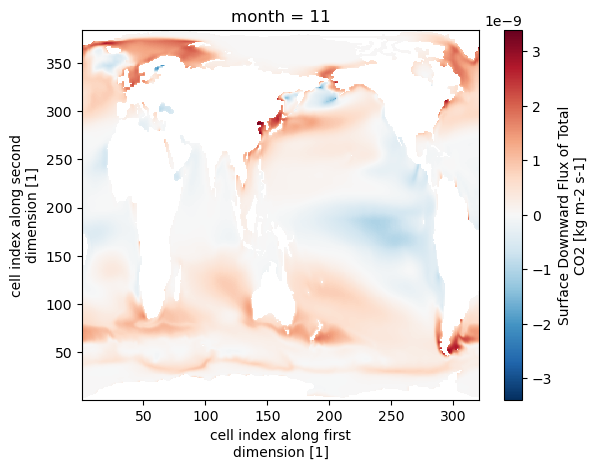

In [148]:
fgco2_hist_monthly_cl.sel(month = 11).plot()

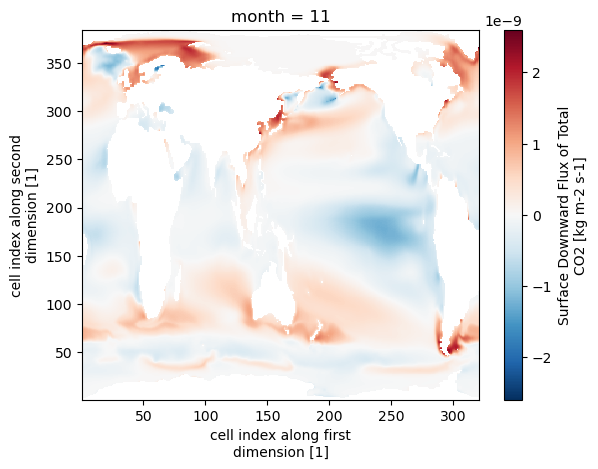

In [149]:
fgco2_pi_monthly_cl.sel(month = 11).plot()

In [126]:
# clef.nci.org.au

In [98]:
ds = zt.open_model(
    'EC-Earth3',
    variables=["tos","sos", "siu","siv"],              # optional
    time_range=("1979","2014"),# optional
    # engine="netcdf4",                       # optional
)

In [107]:
fgco2 = zt_fgco2.open_model(
    'IPSL-CM6A-LR',
    variables=["fgco2"],              # optional
    time_range=("1979","2014"),# optional
    # engine="netcdf4",                       # optional
)

In [194]:
# r

In [197]:
import requests

url = "https://esgf-node.llnl.gov/esg-search/search/"
# url = "https://esgf-node.ornl.gov/esg-search/search/"

# search
params = {
    "project": "CMIP6",
    "experiment_id": "historical",
    "variable_id": "fgco2",
    "member_id": "r1i1p1f1",
    "table_id":"Omon",
    "latest": "true",
    "format": "application/solr+json",  
    "limit": 100,
}

r = requests.get(url, params=params)
resp = r.json()

instances = {
    doc["instance_id"][0] if isinstance(doc.get("instance_id"), list) else doc.get("instance_id")
    for doc in resp["response"]["docs"]
    if "instance_id" in doc
}

instances_sorted = sorted(instances)

for inst in instances_sorted:
    print(inst)


CMIP6.CMIP.BCC.BCC-CSM2-MR.historical.r1i1p1f1.Omon.fgco2.gn.v20181126
CMIP6.CMIP.BCC.BCC-ESM1.historical.r1i1p1f1.Omon.fgco2.gn.v20191121
CMIP6.CMIP.CCCma.CanESM5-1.historical.r1i1p1f1.Omon.fgco2.gn.v20190429
CMIP6.CMIP.CCCma.CanESM5.historical.r1i1p1f1.Omon.fgco2.gn.v20190429
CMIP6.CMIP.CMCC.CMCC-ESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20210114
CMIP6.CMIP.CSIRO.ACCESS-ESM1-5.historical.r1i1p1f1.Omon.fgco2.gn.v20191115
CMIP6.CMIP.EC-Earth-Consortium.EC-Earth3-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20210113
CMIP6.CMIP.HAMMOZ-Consortium.MPI-ESM-1-2-HAM.historical.r1i1p1f1.Omon.fgco2.gn.v20190627
CMIP6.CMIP.INM.INM-CM4-8.historical.r1i1p1f1.Omon.fgco2.gr1.v20190530
CMIP6.CMIP.INM.INM-CM5-0.historical.r1i1p1f1.Omon.fgco2.gr1.v20190610
CMIP6.CMIP.IPSL.IPSL-CM5A2-INCA.historical.r1i1p1f1.Omon.fgco2.gn.v20200729
CMIP6.CMIP.IPSL.IPSL-CM6A-LR-INCA.historical.r1i1p1f1.Omon.fgco2.gn.v20210216
CMIP6.CMIP.IPSL.IPSL-CM6A-LR.historical.r1i1p1f1.Omon.fgco2.gn.v20180803
CMIP6.CMIP.MPI-M.MPI-ESM1-2-HR.h

In [204]:

def make_local_keys(sid_df: pd.DataFrame) -> set[str]:
    need = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label","version"]
    missing = [c for c in need if c not in sid_df.columns]
    if missing:
        raise KeyError(f"Local catalog missing columns: {missing}")
    df = sid_df.copy()
    # ensure str
    for c in need:
        df[c] = df[c].astype(str)
    # build composite key similar to instance_id (minus activity/institution)
    return set(df.apply(
        lambda r: ".".join([r["source_id"], r["experiment_id"], r["member_id"],
                            r["table_id"], r["variable_id"], r["grid_label"], f"v{r['version'].lstrip('v')}"]),
        axis=1
    ).tolist())


In [207]:
v_local = cmip6.search(
    experiment_id="historical",
    variable_id="fgco2",
    member_id="r1i1p1f1",
    table_id="Omon",
)

local_keys = make_local_keys(v_local.df)
print("Local entries:", len(local_keys))
local_keys

Local entries: 22


{'BCC-CSM2-MR.historical.r1i1p1f1.Omon.fgco2.gn.v20181126',
 'BCC-ESM1.historical.r1i1p1f1.Omon.fgco2.gn.v20191121',
 'CESM2-FV2.historical.r1i1p1f1.Omon.fgco2.gn.v20191120',
 'CESM2-FV2.historical.r1i1p1f1.Omon.fgco2.gr.v20191120',
 'CESM2-WACCM-FV2.historical.r1i1p1f1.Omon.fgco2.gn.v20191120',
 'CESM2-WACCM-FV2.historical.r1i1p1f1.Omon.fgco2.gr.v20191120',
 'CESM2-WACCM.historical.r1i1p1f1.Omon.fgco2.gn.v20190808',
 'CESM2-WACCM.historical.r1i1p1f1.Omon.fgco2.gr.v20190808',
 'CESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20190308',
 'CESM2.historical.r1i1p1f1.Omon.fgco2.gr.v20190308',
 'CanESM5.historical.r1i1p1f1.Omon.fgco2.gn.v20190429',
 'GFDL-CM4.historical.r1i1p1f1.Omon.fgco2.gr.v20180701',
 'GFDL-ESM4.historical.r1i1p1f1.Omon.fgco2.gr.v20190726',
 'INM-CM4-8.historical.r1i1p1f1.Omon.fgco2.gr1.v20190530',
 'INM-CM5-0.historical.r1i1p1f1.Omon.fgco2.gr1.v20190610',
 'IPSL-CM6A-LR.historical.r1i1p1f1.Omon.fgco2.gn.v20180803',
 'MPI-ESM-1-2-HAM.historical.r1i1p1f1.Omon.fgco2.gn.v20190627

In [198]:
# resp["response"]["docs"][8]


In [208]:
import requests
import pandas as pd

def _first(x):
    return x[0] if isinstance(x, list) else x

def make_local_keys(sid_df: pd.DataFrame) -> set[str]:
    need = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label","version"]
    missing = [c for c in need if c not in sid_df.columns]
    if missing:
        raise KeyError(f"Local catalog missing columns: {missing}")
    df = sid_df.copy()
    # ensure str
    for c in need:
        df[c] = df[c].astype(str)
    # build composite key similar to instance_id (minus activity/institution)
    return set(df.apply(
        lambda r: ".".join([r["source_id"], r["experiment_id"], r["member_id"],
                            r["table_id"], r["variable_id"], r["grid_label"], f"v{r['version'].lstrip('v')}"]),
        axis=1
    ).tolist())

def make_online_keys(docs: list[dict]) -> set[str]:
    keys = set()
    for d in docs:
        # use explicit fields if present; fallback to parsing instance_id if needed
        src  = _first(d.get("source_id"))
        exp  = _first(d.get("experiment_id"))
        mem  = _first(d.get("member_id"))
        tab  = _first(d.get("table_id"))
        var  = _first(d.get("variable_id"))
        grid = _first(d.get("grid_label"))
        ver  = _first(d.get("version"))
        if all([src,exp,mem,tab,var,grid,ver]):
            keys.add(".".join([src,exp,mem,tab,var,grid,f"v{str(ver).lstrip('v')}"]))
        else:
            # fallback: parse instance_id string if some fields missing
            inst = _first(d.get("instance_id"))
            if inst:
                # example: CMIP6.CMIP.NCAR.CESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20200101
                parts = inst.split(".")
                if len(parts) >= 10:
                    src, exp, mem, tab, var, grid, ver = parts[4], parts[5], parts[6], parts[7], parts[8], parts[9], parts[-1]
                    keys.add(".".join([src,exp,mem,tab,var,grid,ver]))
    return keys

# ---- Local via intake ----
sid_local = cmip6.search(
    experiment_id="historical",
    variable_id="fgco2",
    member_id="r1i1p1f1",
    table_id="Omon",
)
local_keys = make_local_keys(sid_local.df)
print("Local entries:", len(local_keys))

# ---- Online via ESGF ----
url = "https://esgf-node.llnl.gov/esg-search/search/"
params = {
    "project": "CMIP6",
    "experiment_id": "historical",
    "variable_id": "fgco2",
    "member_id": "r1i1p1f1",
    "table_id": "Omon",
    "type": "Dataset",
    "latest": "true",
    "format": "application/solr+json",
    "limit": 10000,
}
r = requests.get(url, params=params, timeout=60)
resp = r.json()
docs = resp["response"]["docs"]
online_keys = make_online_keys(docs)
print("Online entries:", len(online_keys))

# ---- Compare ----
only_local  = sorted(local_keys - online_keys)
only_online = sorted(online_keys - local_keys)
common      = sorted(local_keys & online_keys)

print("Common:", len(common))
print("Only local:", len(only_local))
print("Only online:", len(only_online))

# peek a few
print("Only local sample:", only_local[:5])
print("Only online sample:", only_online[:5])


Local entries: 22
Online entries: 28
Common: 20
Only local: 2
Only online: 8
Only local sample: ['NorCPM1.historical.r1i1p1f1.Omon.fgco2.gn.v20190914', 'NorESM2-LM.historical.r1i1p1f1.Omon.fgco2.gn.v20190815']
Only online sample: ['ACCESS-ESM1-5.historical.r1i1p1f1.Omon.fgco2.gn.v20191115', 'CMCC-ESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20210114', 'CanESM5-1.historical.r1i1p1f1.Omon.fgco2.gn.v20190429', 'EC-Earth3-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20210113', 'GISS-E2-1-G-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20190815']


In [209]:
only_local 


['NorCPM1.historical.r1i1p1f1.Omon.fgco2.gn.v20190914',
 'NorESM2-LM.historical.r1i1p1f1.Omon.fgco2.gn.v20190815']

In [210]:
online_keys

{'ACCESS-ESM1-5.historical.r1i1p1f1.Omon.fgco2.gn.v20191115',
 'BCC-CSM2-MR.historical.r1i1p1f1.Omon.fgco2.gn.v20181126',
 'BCC-ESM1.historical.r1i1p1f1.Omon.fgco2.gn.v20191121',
 'CESM2-FV2.historical.r1i1p1f1.Omon.fgco2.gn.v20191120',
 'CESM2-FV2.historical.r1i1p1f1.Omon.fgco2.gr.v20191120',
 'CESM2-WACCM-FV2.historical.r1i1p1f1.Omon.fgco2.gn.v20191120',
 'CESM2-WACCM-FV2.historical.r1i1p1f1.Omon.fgco2.gr.v20191120',
 'CESM2-WACCM.historical.r1i1p1f1.Omon.fgco2.gn.v20190808',
 'CESM2-WACCM.historical.r1i1p1f1.Omon.fgco2.gr.v20190808',
 'CESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20190308',
 'CESM2.historical.r1i1p1f1.Omon.fgco2.gr.v20190308',
 'CMCC-ESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20210114',
 'CanESM5-1.historical.r1i1p1f1.Omon.fgco2.gn.v20190429',
 'CanESM5.historical.r1i1p1f1.Omon.fgco2.gn.v20190429',
 'EC-Earth3-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20210113',
 'GFDL-CM4.historical.r1i1p1f1.Omon.fgco2.gr.v20180701',
 'GFDL-ESM4.historical.r1i1p1f1.Omon.fgco2.gr.v20190726',
 

In [211]:
import pandas as pd
import requests

def _vernum(x):
    # 'v20200101' -> 20200101, '20200101' -> 20200101, else 0
    s = str(x).lstrip("v")
    try:
        return int(s)
    except Exception:
        return 0

# ---- Local (keep only newest version) ----
sid_local = cmip6.search(
    experiment_id="historical",
    variable_id="fgco2",
    member_id="r1i1p1f1",
    table_id="Omon",
)
df = sid_local.df.copy()
df["version_num"] = df["version"].apply(_vernum)

cols = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label"]
# newest per (model, exp, member, table, var, grid)
latest_local = (df.sort_values(["version_num"])
                  .drop_duplicates(subset=cols, keep="last"))

local_keys = set(
    latest_local.apply(lambda r: ".".join([
        r["source_id"], r["experiment_id"], r["member_id"],
        r["table_id"], r["variable_id"], r["grid_label"], f"v{str(r['version']).lstrip('v')}"
    ]), axis=1)
)

# ---- Online (latest=true) ----
url = "https://esgf-node.llnl.gov/esg-search/search/"
params = {
    "project": "CMIP6",
    "experiment_id": "historical",
    "variable_id": "fgco2",
    "member_id": "r1i1p1f1",
    "table_id": "Omon",
    "type": "Dataset",
    "latest": "true",
    "format": "application/solr+json",
    "limit": 10000,
}
resp = requests.get(url, params=params, timeout=60).json()
docs = resp["response"]["docs"]

def _first(x): return x[0] if isinstance(x, list) else x
online_keys = set()
for d in docs:
    src  = _first(d.get("source_id"))
    exp  = _first(d.get("experiment_id"))
    mem  = _first(d.get("member_id"))
    tab  = _first(d.get("table_id"))
    var  = _first(d.get("variable_id"))
    grid = _first(d.get("grid_label"))
    ver  = _first(d.get("version"))
    if all([src,exp,mem,tab,var,grid,ver]):
        online_keys.add(".".join([src,exp,mem,tab,var,grid,f"v{str(ver).lstrip('v')}"]))

# ---- Compare ----
only_local  = sorted(local_keys - online_keys)
only_online = sorted(online_keys - local_keys)
common      = sorted(local_keys & online_keys)

print("Common:", len(common))
print("Only local (after latest filter):", len(only_local))
print("Only online:", len(only_online))


Common: 20
Only local (after latest filter): 2
Only online: 8


In [212]:
only_online

['ACCESS-ESM1-5.historical.r1i1p1f1.Omon.fgco2.gn.v20191115',
 'CMCC-ESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20210114',
 'CanESM5-1.historical.r1i1p1f1.Omon.fgco2.gn.v20190429',
 'EC-Earth3-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20210113',
 'GISS-E2-1-G-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20190815',
 'IPSL-CM5A2-INCA.historical.r1i1p1f1.Omon.fgco2.gn.v20200729',
 'IPSL-CM6A-LR-INCA.historical.r1i1p1f1.Omon.fgco2.gn.v20210216',
 'NorCPM1.historical.r1i1p1f1.Omon.fgco2.gn.v20200724']

In [15]:
url = "https://esgf-node.llnl.gov/esg-search/search/"
params = {
    "project": "CMIP6",
    "experiment_id": "historical",
    "variable_id": "fgco2",
    "member_id": "r1i1p1f1",
    "table_id": "Omon",
    "type": "Dataset",
    "latest": "true",
    "format": "application/solr+json",
    "limit": 10000,
}
r = requests.get(url, params=params, timeout=60)
resp = r.json()

In [26]:
instance_id_list = []
for doc in resp["response"]["docs"]:
    instance_id_list.append(doc["instance_id"])
    # print(doc["instance_id"])

In [45]:
# resp["response"]

In [47]:
np.unique(np.sort(instance_id_list))

array(['CMIP6.CMIP.BCC.BCC-CSM2-MR.historical.r1i1p1f1.Omon.fgco2.gn.v20181126',
       'CMIP6.CMIP.BCC.BCC-ESM1.historical.r1i1p1f1.Omon.fgco2.gn.v20191121',
       'CMIP6.CMIP.CCCma.CanESM5-1.historical.r1i1p1f1.Omon.fgco2.gn.v20190429',
       'CMIP6.CMIP.CCCma.CanESM5.historical.r1i1p1f1.Omon.fgco2.gn.v20190429',
       'CMIP6.CMIP.CMCC.CMCC-ESM2.historical.r1i1p1f1.Omon.fgco2.gn.v20210114',
       'CMIP6.CMIP.CSIRO.ACCESS-ESM1-5.historical.r1i1p1f1.Omon.fgco2.gn.v20191115',
       'CMIP6.CMIP.EC-Earth-Consortium.EC-Earth3-CC.historical.r1i1p1f1.Omon.fgco2.gn.v20210113',
       'CMIP6.CMIP.HAMMOZ-Consortium.MPI-ESM-1-2-HAM.historical.r1i1p1f1.Omon.fgco2.gn.v20190627',
       'CMIP6.CMIP.INM.INM-CM4-8.historical.r1i1p1f1.Omon.fgco2.gr1.v20190530',
       'CMIP6.CMIP.INM.INM-CM5-0.historical.r1i1p1f1.Omon.fgco2.gr1.v20190610',
       'CMIP6.CMIP.IPSL.IPSL-CM5A2-INCA.historical.r1i1p1f1.Omon.fgco2.gn.v20200729',
       'CMIP6.CMIP.IPSL.IPSL-CM6A-LR-INCA.historical.r1i1p1f1.Omon.fgco2.

## Find the dataset not stored locally

In [11]:
import requests
import pandas as pd

ESGF_NODES_DEFAULT = [
    "https://esgf-node.llnl.gov/esg-search/search/",
    "https://esgf-data.dkrz.de/esg-search/search/",
    "https://esgf-node.ipsl.upmc.fr/esg-search/search/",
    "https://esgf.nci.org.au/esg-search/search/",
    "https://esgf-node.ornl.gov/esg-search/search/",
]

def _first(x):
    return x[0] if isinstance(x, list) else x

def _vernum(x):
    s = str(x).lstrip("v")
    try:
        return int(s)
    except Exception:
        return 0

def _ensure_list(v):
    if v is None: return None
    return v if isinstance(v, (list, tuple, set)) else [v]

def _local_latest_df(df: pd.DataFrame) -> pd.DataFrame:
    need = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label","version"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"Local catalog missing columns: {missing}")
    d = df.copy()
    d["version_num"] = d["version"].apply(_vernum)
    group_cols = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label"]
    return (d.sort_values(group_cols + ["version_num"])
              .drop_duplicates(subset=group_cols, keep="last"))

def _build_keys_from_df(df: pd.DataFrame, include_version: bool) -> set[str]:
    cols = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label"]
    if include_version:
        return set(df.apply(lambda r: ".".join([
            r["source_id"], r["experiment_id"], r["member_id"],
            r["table_id"], r["variable_id"], r["grid_label"], f"v{str(r['version']).lstrip('v')}"
        ]), axis=1).tolist())
    else:
        return set(df.apply(lambda r: ".".join([
            r["source_id"], r["experiment_id"], r["member_id"],
            r["table_id"], r["variable_id"], r["grid_label"]
        ]), axis=1).tolist())

def _base_and_versions_from_df(df: pd.DataFrame):
    """Return base_key -> set(versions as 'vYYYYMMDD') from local df (all rows)."""
    out = {}
    for _, r in df.iterrows():
        base = (r["source_id"], r["experiment_id"], r["member_id"],
                r["table_id"], r["variable_id"], r["grid_label"])
        ver  = f"v{str(r['version']).lstrip('v')}"
        out.setdefault(base, set()).add(ver)
    return out

def _esgf_query(constraints: dict, latest: bool, limit: int, nodes: list[str] | None):
    nodes = nodes or ESGF_NODES_DEFAULT
    params = {
        "project": constraints.get("project", "CMIP6"),
        "type": "Dataset",
        "latest": str(latest).lower(),
        "format": "application/solr+json",
        "limit": str(limit),
        "offset": "0",
    }
    for k in ["experiment_id","variable_id","member_id","table_id","source_id","grid_label","institution_id","activity_id"]:
        v = constraints.get(k)
        if v is not None:
            params[k] = _ensure_list(v)

    headers = {"Accept": "application/solr+json", "User-Agent": "requests-esgf-compare"}
    last_err = None
    for base in nodes:
        try:
            r = requests.get(base, params=params, headers=headers, timeout=30)
            if r.status_code != 200:
                last_err = f"HTTP {r.status_code} from {base}"
                continue
            try:
                data = r.json()
            except Exception as e:
                last_err = f"JSON parse failed from {base}: {e}"
                continue
            docs = data.get("response", {}).get("docs", [])
            if docs:
                return base, docs
        except requests.RequestException as e:
            last_err = e
            continue
    raise RuntimeError(f"No ESGF node returned usable results. Last error: {last_err}")

def _base_and_versions_from_docs(docs: list[dict]):
    """Return base_key -> set(versions as 'vYYYYMMDD') from ESGF docs."""
    out = {}
    for d in docs:
        src  = _first(d.get("source_id"))
        exp  = _first(d.get("experiment_id"))
        mem  = _first(d.get("member_id"))
        tab  = _first(d.get("table_id"))
        var  = _first(d.get("variable_id"))
        grid = _first(d.get("grid_label"))
        ver  = _first(d.get("version"))
        # fallback: parse instance_id if fields missing
        if not all([src,exp,mem,tab,var,grid]):
            inst = _first(d.get("instance_id"))
            if inst:
                parts = inst.split(".")
                # CMIP6.CMIP.<inst>.<src>.<exp>.<mem>.<tab>.<var>.<grid>.<ver>
                if len(parts) >= 10:
                    src, exp, mem, tab, var, grid = parts[3], parts[4], parts[5], parts[6], parts[7], parts[8]
                    ver = parts[9]
        if not all([src,exp,mem,tab,var,grid]):
            continue
        if ver is None:
            continue
        ver = f"v{str(ver).lstrip('v')}"
        base = (src, exp, mem, tab, var, grid)
        out.setdefault(base, set()).add(ver)
    return out

def _summarize_version_mismatch(local_map, online_map):
    """Return dict base_key -> details when versions differ."""
    result = {}
    common_bases = set(local_map) & set(online_map)
    for base in sorted(common_bases):
        lv = local_map[base]
        ov = online_map[base]
        if lv == ov:
            status = "same"
        else:
            lmax = max((_vernum(v) for v in lv), default=0)
            omax = max((_vernum(v) for v in ov), default=0)
            if lmax < omax:
                status = "local older"
            elif lmax > omax:
                status = "local newer"
            else:
                status = "different sets"
        if status != "same":
            result[".".join(base)] = {
                "local_versions": sorted(lv),
                "online_versions": sorted(ov),
                "local_max": f"v{lmax}" if lv else None,
                "online_max": f"v{omax}" if ov else None,
                "status": status,
            }
    return result

def compare_local_vs_online(cmip6, constraints: dict, mode: str = "latest",
                            limit: int = 10000, nodes: list[str] | None = None):
    """
    Compare local intake catalog vs ESGF online for given constraints.

    mode:
      - "latest": compare newest local per base key against ESGF latest.
      - "ignore_version": compare existence (version-agnostic).
      - "all_versions": compare all versions vs ESGF (latest=false).
    Additionally returns a 'version_mismatch' map showing bases present on both
    sides where versions differ (independent of 'mode').
    """
    cons = dict(constraints)
    if "variable" in cons and "variable_id" not in cons:
        cons["variable_id"] = cons.pop("variable")

    # Local rows (all)
    sid_local = cmip6.search(**cons)
    df_local_all = sid_local.df.copy()
    if not {"version","grid_label"}.issubset(df_local_all.columns):
        missing = {"version","grid_label"} - set(df_local_all.columns)
        raise KeyError(f"Local catalog missing columns: {missing}")

    # Build local sets as per mode
    if mode == "latest":
        df_local_latest = _local_latest_df(df_local_all)
        local_keys = _build_keys_from_df(df_local_latest, include_version=True)
    elif mode == "ignore_version":
        local_keys = _build_keys_from_df(df_local_all, include_version=False)
    elif mode == "all_versions":
        local_keys = _build_keys_from_df(df_local_all, include_version=True)
    else:
        raise ValueError("mode must be one of: 'latest', 'ignore_version', 'all_versions'.")

    # Online docs
    node_used, docs = _esgf_query(cons, latest=(mode != "all_versions"), limit=limit, nodes=nodes)

    # Build online sets as per mode
    online_base_versions = _base_and_versions_from_docs(docs)
    if mode == "ignore_version":
        online_keys = set(".".join(k) for k in online_base_versions.keys())
    else:
        online_keys = set(".".join((*k, v)) for k, vers in online_base_versions.items() for v in vers)

    # Build local base->versions map (for version mismatch report)
    local_base_versions = _base_and_versions_from_df(df_local_all)

    # Compare sets (for parity)
    only_local  = sorted(local_keys - online_keys)
    only_online = sorted(online_keys - local_keys)
    common      = sorted(local_keys & online_keys)

    # Version-only differences (bases present both sides but version sets differ)
    version_mismatch = _summarize_version_mismatch(local_base_versions, online_base_versions)

    return {
        "node": node_used,
        "mode": mode,
        "common": common,
        "only_local": only_local,
        "only_online": only_online,
        "local_count": len(local_keys),
        "online_count": len(online_keys),
        "version_mismatch": version_mismatch,  # base -> details (only where versions differ)
    }


In [12]:
def compare_local_vs_online(cmip6, constraints: dict, mode: str = "latest",
                            limit: int = 10000, nodes: list[str] | None = None):
    """
    Compare local intake catalog vs ESGF online for given constraints.

    mode:
      - "latest": compare newest local per base key against ESGF latest.
      - "ignore_version": compare existence (version-agnostic).
      - "all_versions": compare all versions vs ESGF (latest=false).
    Additionally returns:
      - version_mismatch (bases present both sides but versions differ)
      - local_models / online_models (unique source_id)
    """
    cons = dict(constraints)
    if "variable" in cons and "variable_id" not in cons:
        cons["variable_id"] = cons.pop("variable")

    # --- Local rows (all) ---
    sid_local = cmip6.search(**cons)
    df_local_all = sid_local.df.copy()
    if not {"version","grid_label"}.issubset(df_local_all.columns):
        missing = {"version","grid_label"} - set(df_local_all.columns)
        raise KeyError(f"Local catalog missing columns: {missing}")

    local_models = sorted(df_local_all["source_id"].unique())

    # --- Local keys (depending on mode) ---
    if mode == "latest":
        df_local_latest = _local_latest_df(df_local_all)
        local_keys = _build_keys_from_df(df_local_latest, include_version=True)
    elif mode == "ignore_version":
        local_keys = _build_keys_from_df(df_local_all, include_version=False)
    elif mode == "all_versions":
        local_keys = _build_keys_from_df(df_local_all, include_version=True)
    else:
        raise ValueError("mode must be one of: 'latest', 'ignore_version', 'all_versions'.")

    # --- Online docs ---
    node_used, docs = _esgf_query(cons, latest=(mode != "all_versions"), limit=limit, nodes=nodes)

    # --- Online models ---
    online_models = sorted({_first(d.get("source_id")) for d in docs if d.get("source_id")})

    # --- Online keys ---
    online_base_versions = _base_and_versions_from_docs(docs)
    if mode == "ignore_version":
        online_keys = set(".".join(k) for k in online_base_versions.keys())
    else:
        online_keys = set(".".join((*k, v)) for k, vers in online_base_versions.items() for v in vers)

    # --- Local base->versions for mismatch check ---
    local_base_versions = _base_and_versions_from_df(df_local_all)

    # --- Compare ---
    only_local  = sorted(local_keys - online_keys)
    only_online = sorted(online_keys - local_keys)
    common      = sorted(local_keys & online_keys)

    version_mismatch = _summarize_version_mismatch(local_base_versions, online_base_versions)

    return {
        "node": node_used,
        "mode": mode,
        "common": common,
        "only_local": only_local,
        "only_online": only_online,
        "local_count": len(local_keys),
        "online_count": len(online_keys),
        "version_mismatch": version_mismatch,
        "local_models": local_models,
        "online_models": online_models,
    }


In [77]:
res = compare_local_vs_online(
    cmip6,
    constraints=dict(
        experiment_id="historical",
        variable_id="fgco2",
        member_id="r1i1p1f1",
        table_id="Omon",
    ),
    mode="latest",   # or "ignore_version" / "all_versions"
)

print("Node:", res["node"])
print("Parity (latest mode) → local:", res["local_count"], "online:", res["online_count"])
# print("Only local example:", res["only_local"][:3])
# print("Only online example:", res["only_online"][:3])

# Version-only differences:
print("Version mismatches:", len(res["version_mismatch"]))
for base, det in list(res["version_mismatch"].items())[:3]:
    print(base, det["status"], det["local_versions"], det["online_versions"])


Node: https://esgf-node.llnl.gov/esg-search/search/
Parity (latest mode) → local: 22 online: 28
Version mismatches: 1
NorCPM1.historical.r1i1p1f1.Omon.fgco2.gn local older ['v20190914'] ['v20200724']


In [13]:
res = compare_local_vs_online(
    cmip6,
    constraints=dict(
        # experiment_id="historical",
        experiment_id="piControl",
        variable_id="fgco2",
        member_id="r1i1p1f1",
        table_id="Omon",
    ),
    mode="latest",
)

print("Node used:", res["node"])
print("Unique local models:", len(res["local_models"]))
print("Unique online models:", len(res["online_models"]))

# model comparison
# print("Only local models:", sorted(set(res["local_models"]) - set(res["online_models"])))
print("Only online models:", sorted(set(res["online_models"]) - set(res["local_models"])))
# print("Common models:", sorted(set(res["local_models"]) & set(res["online_models"])))
# Version-only differences:
print("Version mismatches:", len(res["version_mismatch"]))
for base, det in list(res["version_mismatch"].items())[:3]:
    print(base, det["status"], det["local_versions"], det["online_versions"])

Node used: https://esgf-node.llnl.gov/esg-search/search/
Unique local models: 16
Unique online models: 24
Only online models: ['ACCESS-ESM1-5', 'CMCC-ESM2', 'CanESM5-1', 'EC-Earth3-CC', 'GISS-E2-1-G-CC', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-MR1', 'MPI-ESM-1-2-HAM', 'NorESM2-LM']
Version mismatches: 0


In [14]:
res['only_online']

['ACCESS-ESM1-5.piControl.r1i1p1f1.Omon.fgco2.gn.v20210316',
 'CMCC-ESM2.piControl.r1i1p1f1.Omon.fgco2.gn.v20210304',
 'CanESM5-1.piControl.r1i1p1f1.Omon.fgco2.gn.v20190429',
 'EC-Earth3-CC.piControl.r1i1p1f1.Omon.fgco2.gn.v20210416',
 'GISS-E2-1-G-CC.piControl.r1i1p1f1.Omon.fgco2.gn.v20190815',
 'IPSL-CM5A2-INCA.piControl.r1i1p1f1.Omon.fgco2.gn.v20210216',
 'IPSL-CM6A-MR1.piControl.r1i1p1f1.Omon.fgco2.gn.v20231229',
 'MPI-ESM-1-2-HAM.piControl.r1i1p1f1.Omon.fgco2.gn.v20200120',
 'NorESM2-LM.piControl.r1i1p1f1.Omon.fgco2.gn.v20210118']

In [70]:
import requests
import pandas as pd

# --- helpers you already have (or from earlier snippets) ---
def _first(x):
    return x[0] if isinstance(x, list) else x

def _vernum(x):
    s = str(x).lstrip("v")
    try: return int(s)
    except Exception: return 0

def _ensure_list(v):
    if v is None: return None
    return v if isinstance(v, (list, tuple, set)) else [v]

def _local_latest_df(df: pd.DataFrame) -> pd.DataFrame:
    need = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label","version"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"Local catalog missing columns: {missing}")
    d = df.copy()
    d["version_num"] = d["version"].apply(_vernum)
    group_cols = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label"]
    return (d.sort_values(group_cols + ["version_num"])
              .drop_duplicates(subset=group_cols, keep="last"))

def _build_keys_from_df(df: pd.DataFrame, include_version: bool) -> set[str]:
    cols = ["source_id","experiment_id","member_id","table_id","variable_id","grid_label"]
    if include_version:
        return set(df.apply(lambda r: ".".join([
            r["source_id"], r["experiment_id"], r["member_id"],
            r["table_id"], r["variable_id"], r["grid_label"], f"v{str(r['version']).lstrip('v')}"
        ]), axis=1).tolist())
    else:
        return set(df.apply(lambda r: ".".join([
            r["source_id"], r["experiment_id"], r["member_id"],
            r["table_id"], r["variable_id"], r["grid_label"]
        ]), axis=1).tolist())

ESGF_NODES_DEFAULT = [
    "https://esgf-node.llnl.gov/esg-search/search/",
    "https://esgf-data.dkrz.de/esg-search/search/",
    "https://esgf-node.ipsl.upmc.fr/esg-search/search/",
    "https://esgf.nci.org.au/esg-search/search/",
    "https://esgf-node.ornl.gov/esg-search/search/",
]

def _esgf_query(constraints: dict, latest: bool, limit: int, nodes: list[str] | None):
    nodes = nodes or ESGF_NODES_DEFAULT
    params = {
        "project": constraints.get("project", "CMIP6"),
        "type": "Dataset",
        "latest": str(latest).lower(),
        "format": "application/solr+json",
        "limit": str(limit),
        "offset": "0",
    }
    for k in ["experiment_id","variable_id","member_id","table_id","source_id","grid_label","institution_id","activity_id"]:
        v = constraints.get(k)
        if v is not None:
            params[k] = _ensure_list(v)

    headers = {"Accept": "application/solr+json", "User-Agent": "requests-esgf-compare"}
    last_err = None
    for base in nodes:
        try:
            r = requests.get(base, params=params, headers=headers, timeout=30)
            if r.status_code != 200:
                last_err = f"HTTP {r.status_code} from {base}"
                continue
            try:
                data = r.json()
            except Exception as e:
                last_err = f"JSON parse failed from {base}: {e}"
                continue
            docs = data.get("response", {}).get("docs", [])
            if docs:
                return base, docs
        except requests.RequestException as e:
            last_err = e
            continue
    raise RuntimeError(f"No ESGF node returned usable results. Last error: {last_err}")

def _base_and_versions_from_df(df: pd.DataFrame):
    out = {}
    for _, r in df.iterrows():
        base = (r["source_id"], r["experiment_id"], r["member_id"],
                r["table_id"], r["variable_id"], r["grid_label"])
        ver  = f"v{str(r['version']).lstrip('v')}"
        out.setdefault(base, set()).add(ver)
    return out

def _base_and_versions_from_docs(docs: list[dict]):
    out = {}
    for d in docs:
        src  = _first(d.get("source_id"))
        exp  = _first(d.get("experiment_id"))
        mem  = _first(d.get("member_id"))
        tab  = _first(d.get("table_id"))
        var  = _first(d.get("variable_id"))
        grid = _first(d.get("grid_label"))
        ver  = _first(d.get("version"))
        if not all([src,exp,mem,tab,var,grid]):
            inst = _first(d.get("instance_id"))
            if inst:
                parts = inst.split(".")
                if len(parts) >= 10:
                    src, exp, mem, tab, var, grid = parts[3], parts[4], parts[5], parts[6], parts[7], parts[8]
                    ver = parts[9]
        if not all([src,exp,mem,tab,var,grid]):  # still incomplete
            continue
        if ver is None:
            continue
        ver = f"v{str(ver).lstrip('v')}"
        base = (src, exp, mem, tab, var, grid)
        out.setdefault(base, set()).add(ver)
    return out

def _summarize_version_mismatch(local_map, online_map):
    result = {}
    common_bases = set(local_map) & set(online_map)
    for base in sorted(common_bases):
        lv = local_map[base]
        ov = online_map[base]
        if lv == ov:
            continue
        lmax = max((_vernum(v) for v in lv), default=0)
        omax = max((_vernum(v) for v in ov), default=0)
        if lmax < omax:
            status = "local older"
        elif lmax > omax:
            status = "local newer"
        else:
            status = "different sets"
        result[".".join(base)] = {
            "local_versions": sorted(lv),
            "online_versions": sorted(ov),
            "local_max": f"v{lmax}" if lv else None,
            "online_max": f"v{omax}" if ov else None,
            "status": status,
        }
    return result

# --- NEW: pull official ESGF IDs and map them to our comparison keys ---
def _ids_map_from_docs(docs: list[dict]):
    """
    Returns:
      - key_to_dataset_ids: {base_with_version_key -> set(dataset_id)}
      - key_to_instance_ids: {base_with_version_key -> set(instance_id)}
    where base_with_version_key == "source.exp.member.table.var.grid.vYYYYMMDD"
    """
    key_to_dataset_ids = {}
    key_to_instance_ids = {}
    for d in docs:
        src  = _first(d.get("source_id"))
        exp  = _first(d.get("experiment_id"))
        mem  = _first(d.get("member_id"))
        tab  = _first(d.get("table_id"))
        var  = _first(d.get("variable_id"))
        grid = _first(d.get("grid_label"))
        ver  = _first(d.get("version"))
        if not all([src,exp,mem,tab,var,grid,ver]):
            # if some fields missing, skip (or parse from instance_id if you prefer)
            continue
        key = ".".join([src,exp,mem,tab,var,grid,f"v{str(ver).lstrip('v')}"])
        dsid = _first(d.get("dataset_id"))
        inst = _first(d.get("instance_id"))
        if dsid:
            key_to_dataset_ids.setdefault(key, set()).add(dsid)
        if inst:
            key_to_instance_ids.setdefault(key, set()).add(inst)
    return key_to_dataset_ids, key_to_instance_ids

# --- MAIN: now returns instance_id/dataset_id for only-online ---
def compare_local_vs_online(cmip6, constraints: dict, mode: str = "latest",
                            limit: int = 10000, nodes: list[str] | None = None):
    """
    Compare local intake catalog vs ESGF online for given constraints.

    Returns (in addition to previous fields):
      - only_online_dataset_ids: list[str]  # official ESGF dataset_id corresponding to only_online keys
      - only_online_instance_ids: list[str] # ESGF instance_id corresponding to only_online keys
    """
    cons = dict(constraints)
    if "variable" in cons and "variable_id" not in cons:
        cons["variable_id"] = cons.pop("variable")

    # Local (all rows)
    sid_local = cmip6.search(**cons)
    df_local_all = sid_local.df.copy()
    if not {"version","grid_label"}.issubset(df_local_all.columns):
        missing = {"version","grid_label"} - set(df_local_all.columns)
        raise KeyError(f"Local catalog missing columns: {missing}")

    local_models = sorted(df_local_all["source_id"].unique())

    # Local keys per mode
    if mode == "latest":
        df_local_latest = _local_latest_df(df_local_all)
        local_keys = _build_keys_from_df(df_local_latest, include_version=True)
    elif mode == "ignore_version":
        local_keys = _build_keys_from_df(df_local_all, include_version=False)
    elif mode == "all_versions":
        local_keys = _build_keys_from_df(df_local_all, include_version=True)
    else:
        raise ValueError("mode must be one of: 'latest', 'ignore_version', 'all_versions'.")

    # Online docs
    node_used, docs = _esgf_query(cons, latest=(mode != "all_versions"), limit=limit, nodes=nodes)

    # Online models
    online_models = sorted({_first(d.get("source_id")) for d in docs if d.get("source_id")})

    # Online keys
    online_base_versions = _base_and_versions_from_docs(docs)
    if mode == "ignore_version":
        online_keys = set(".".join(k) for k in online_base_versions.keys())
    else:
        online_keys = set(".".join((*k, v)) for k, vers in online_base_versions.items() for v in vers)

    # Local base->versions for mismatch
    local_base_versions = _base_and_versions_from_df(df_local_all)

    # Compare
    only_local  = sorted(local_keys - online_keys)
    only_online = sorted(online_keys - local_keys)
    common      = sorted(local_keys & online_keys)

    version_mismatch = _summarize_version_mismatch(local_base_versions, online_base_versions)

    # --- NEW: map only_online back to official ESGF IDs ---
    key_to_dataset_ids, key_to_instance_ids = _ids_map_from_docs(docs)
    only_online_dataset_ids = sorted({dsid for k in only_online for dsid in key_to_dataset_ids.get(k, [])})
    only_online_instance_ids = sorted({iid for k in only_online for iid in key_to_instance_ids.get(k, [])})

    return {
        "node": node_used,
        "mode": mode,
        "common": common,
        "only_local": only_local,
        "only_online": only_online,
        "local_count": len(local_keys),
        "online_count": len(online_keys),
        "version_mismatch": version_mismatch,
        "local_models": local_models,
        "online_models": online_models,
        "only_online_dataset_ids": only_online_dataset_ids,     # <- added
        "only_online_instance_ids": only_online_instance_ids,   # <- added
    }
# import os

def save_ids_to_file(ids: list[str], filename: str, add_request_note: bool = True):
    """
    Save a list of ESGF dataset/instance IDs to a file, each prefixed with 'dataset_id='.
    Optionally add a final line reminding how to submit to NCI helpdesk.
    """
    with open(filename, "w") as f:
        for dsid in ids:
            f.write(f"dataset_id={dsid}\n")

    print(f"✅ Saved {len(ids)} IDs to {os.path.abspath(filename)}")
    if add_request_note:
        print("Next: open https://help.nci.org.au/ and attach this file to your help request,")
        print("or email help@nci.org.au and attach the file.")


In [50]:
res = compare_local_vs_online(
    cmip6,
    constraints=dict(
        experiment_id="historical",
        variable_id="fgco2",
        member_id="r1i1p1f1",
        table_id="Omon",
    ),
    mode="latest",
)

print("Only-online dataset_ids (first 5):")
for dsid in res["only_online_dataset_ids"][:5]:
    print("dataset_id=" + dsid)

# print("Only


Only-online dataset_ids (first 5):


In [71]:
# Save instance_ids
save_ids_to_file(res["only_online_instance_ids"], "only_online_instance_ids.txt")



✅ Saved 8 IDs to /home/581/zc0441/only_online_instance_ids.txt
Next: open https://help.nci.org.au/ and attach this file to your help request,
or email help@nci.org.au and attach the file.


In [60]:
# res["only_online_instance_ids"]

# Trash can

In [43]:
member_id = ["r1i1p1f1", "r2i1p1f2", "r1i1p1f2"]  
experiment_id="historical",


SImon_cat = cmip6.search(
    experiment_id=experiment_id,
    table_id="SImon",
    member_id=member_id  
)
Omon_cat = cmip6.search(
    experiment_id=experiment_id,
    table_id="Omon",
    member_id=member_id 
)
Amon_cat = cmip6.search(
    experiment_id=experiment_id,
    table_id="Amon",
    member_id=member_id   
)

In [19]:
variable_id = ['fgco2']
fgco2 = Omon_cat.search(variable_id = variable_id)

In [30]:
fgco2.df.source_id.unique()

array(['CESM2-WACCM-FV2', 'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-LR',
       'NorESM2-LM', 'NorESM2-MM', 'GFDL-ESM4', 'NorCPM1',
       'MPI-ESM1-2-HR', 'GFDL-CM4', 'MPI-ESM-1-2-HAM', 'CanESM5',
       'BCC-ESM1', 'UKESM1-0-LL', 'CESM2', 'CNRM-ESM2-1', 'CESM2-FV2',
       'IPSL-CM6A-LR', 'BCC-CSM2-MR', 'CESM2-WACCM', 'MIROC-ES2L'],
      dtype=object)

In [33]:

models = np.sort(fgco2.df.source_id.unique())

In [35]:
models

array(['BCC-CSM2-MR', 'BCC-ESM1', 'CESM2', 'CESM2-FV2', 'CESM2-WACCM',
       'CESM2-WACCM-FV2', 'CNRM-ESM2-1', 'CanESM5', 'GFDL-CM4',
       'GFDL-ESM4', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR',
       'MIROC-ES2L', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR',
       'NorCPM1', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL'], dtype=object)

In [ ]:
Class Ztake


In [12]:

# first_ten_expts = cmip6.keys()[:10]
# catalog_first_ten_expts = cmip6.search(name=first_ten_expts)
# catalog_first_ten_expts.interactive

In [37]:
# import ast, intake
# cat = intake.open_esm_datastore(
#     "/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json",
#     read_csv_kwargs={"converters": {"variable": ast.literal_eval}},  # 注意列名通常是 variable_id
# )


In [52]:
pick_newest(fgco2.df)

/jobfs/148503376.gadi-pbs/ipykernel_3075261/2910506216.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_rows = df.groupby("source_id", group_keys=False).apply(_best)


,path,file_type,realm,frequency,table_id,project_id,institution_id,source_id,experiment_id,member_id,variable_id,grid_label,version,time_range,version_num,member_rank,grid_rank
0,/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-CSM2-...,f,ocnBgchem,mon,Omon,CMIP,BCC,BCC-CSM2-MR,historical,r1i1p1f1,fgco2,gn,v20181126,185001-201412,20181126,0,0
1,/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-ESM1/...,f,ocnBgchem,mon,Omon,CMIP,BCC,BCC-ESM1,historical,r1i1p1f1,fgco2,gn,v20191121,185001-201412,20191121,0,0
2,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2/hi...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2,historical,r1i1p1f1,fgco2,gn,v20190308,185001-201412,20190308,0,0
3,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-FV...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2-FV2,historical,r1i1p1f1,fgco2,gn,v20191120,190001-194912,20191120,0,0
4,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2-WACCM,historical,r1i1p1f1,fgco2,gn,v20190808,185001-201412,20190808,0,0
5,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,f,ocnBgchem,mon,Omon,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,fgco2,gn,v20191120,200001-201412,20191120,0,0
6,/g/data/oi10/replicas/CMIP6/CMIP/CNRM-CERFACS/...,f,ocnBgchem,mon,Omon,CMIP,CNRM-CERFACS,CNRM-ESM2-1,historical,r1i1p1f2,fgco2,gn,v20181206,185001-201412,20181206,1,0
7,/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5...,f,ocnBgchem,mon,Omon,CMIP,CCCma,CanESM5,historical,r1i1p1f1,fgco2,gn,v20190429,185001-201412,20190429,0,0
8,/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFD...,f,ocnBgchem,mon,Omon,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,fgco2,gr,v20180701,197001-198912,20180701,0,1
9,/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFD...,f,ocnBgchem,mon,Omon,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r1i1p1f1,fgco2,gr,v20190726,201001-201412,20190726,0,1


In [38]:
# import pandas as pd

def pick_newest(df, prefer_members=("r1i1p1f1","r1i1p1f2"), prefer_grids=("gn","gr","gr1")):
    # 复制，避免修改原始 df
    df = df.copy()
    
    # 解析 version 成数值
    v = df["version"].astype(str).str.lstrip("v")
    df["version_num"] = pd.to_numeric(v, errors="coerce").fillna(0).astype(int)

    # 给 member/grid 排序优先级
    mem_map = {m: i for i, m in enumerate(prefer_members)}
    grid_map = {g: i for i, g in enumerate(prefer_grids)}
    df["member_rank"] = df["member_id"].map(mem_map).fillna(len(prefer_members)+100).astype(int)
    df["grid_rank"]   = df["grid_label"].map(grid_map).fillna(len(prefer_grids)+100).astype(int)

    # 对每个模型分组，选最佳行
    def _best(group: pd.DataFrame) -> pd.DataFrame:
        return group.sort_values(
            by=["member_rank","grid_rank","version_num"],
            ascending=[True, True, False]
        ).head(1)

    best_rows = df.groupby("source_id", group_keys=False).apply(_best)
    return best_rows.reset_index(drop=True)


In [53]:
best = pick_newest(fgco2.df,
                   prefer_members=("r1i1p1f1","r1i1p1f2"),
                   prefer_grids=("gn","gr","gr1"))

print(best[["source_id","member_id","grid_label","version"]])


          source_id member_id grid_label    version
0       BCC-CSM2-MR  r1i1p1f1         gn  v20181126
1          BCC-ESM1  r1i1p1f1         gn  v20191121
2             CESM2  r1i1p1f1         gn  v20190308
3         CESM2-FV2  r1i1p1f1         gn  v20191120
4       CESM2-WACCM  r1i1p1f1         gn  v20190808
5   CESM2-WACCM-FV2  r1i1p1f1         gn  v20191120
6       CNRM-ESM2-1  r1i1p1f2         gn  v20181206
7           CanESM5  r1i1p1f1         gn  v20190429
8          GFDL-CM4  r1i1p1f1         gr  v20180701
9         GFDL-ESM4  r1i1p1f1         gr  v20190726
10        INM-CM4-8  r1i1p1f1        gr1  v20190530
11        INM-CM5-0  r1i1p1f1        gr1  v20190610
12     IPSL-CM6A-LR  r1i1p1f1         gn  v20180803
13       MIROC-ES2L  r1i1p1f2         gn  v20200124
14  MPI-ESM-1-2-HAM  r1i1p1f1         gn  v20190627
15    MPI-ESM1-2-HR  r1i1p1f1         gn  v20190710
16    MPI-ESM1-2-LR  r1i1p1f1         gn  v20190710
17          NorCPM1  r1i1p1f1         gn  v20190914
18       Nor

/jobfs/148503376.gadi-pbs/ipykernel_3075261/2910506216.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_rows = df.groupby("source_id", group_keys=False).apply(_best)


In [34]:
# cat.interactive

In [24]:
# dask.config.set(scheduler='single-threaded')
# cat = intake.open_esm_datastore(cmip6,read_csv_kwargs={"converters": {"variable": ast.literal_eval}},
# )

In [16]:
import intake
import ast
import dask

# Make sure this is single-threaded
dask.config.set(scheduler='single-threaded')

cat = intake.open_esm_datastore(
    "multi-variable-catalog.json",
    read_csv_kwargs={"converters": {"variable": ast.literal_eval}},
)
cat

FileNotFoundError: [Errno 2] No such file or directory: '/home/581/zc0441/multi-variable-catalog.json'

In [3]:
import pandas as pd
from intake_esm.core import esm_datastore

def newest_per_model(sid, top_catalog, prefer_members=("r1i1p1f1","r1i1p1f2"), chunks={"time":12}):
    """
    sid: cmip6.search(...) 的结果
    top_catalog: 顶层 cmip6 (intake.cat.nci.esgf.cmip6)
    prefer_members: 成员优先顺序
    返回 {模型名: xarray.Dataset}
    """
    df = sid.df.copy()

    # 处理版本号
    df["version_num"] = (
        df["version"].astype(str).str.lstrip("v").apply(lambda x: int(x) if x.isdigit() else 0)
    )

    # 按优先顺序选 member
    keep = []
    for mem in prefer_members:
        tmp = df[df["member_id"] == mem]
        tmp = (
            tmp.sort_values("version_num")
               .drop_duplicates(subset=["source_id","variable_id","grid_label"], keep="last")
        )
        keep.append(tmp)

    df_latest = pd.concat(keep).drop_duplicates(subset=["source_id","variable_id","grid_label"], keep="first")

    # 从顶层 catalog 提取 metadata
    meta = getattr(top_catalog, "esmcol_data", None) or getattr(top_catalog, "esmcol", None)
    if meta is None:
        raise RuntimeError("顶层 catalog 没有 metadata")

    # 重建小 catalog
    cat_new = esm_datastore(df_latest, esmcol_data=meta)

    # 打开数据
    try:
        dsets = cat_new.to_dataset_dict(xarray_open_kwargs={"chunks": chunks})
    except TypeError:
        dsets = cat_new.to_dataset_dict(cdf_kwargs={"chunks": chunks})

    # 简化 key：只保留模型名
    return { (k[0] if isinstance(k, tuple) else k): ds for k, ds in dsets.items() }


In [4]:
print(ds_by_model.keys())  

dict_keys(['CMIP6.CMIP.IPSL.IPSL-CM6A-LR.historical.r1i1p1f1.SImon.sidmassth.gn.v20180803', 'CMIP6.CMIP.NIMS-KMA.KACE-1-0-G.historical.r1i1p1f1.SImon.sidmassth.gr.v20200130', 'CMIP6.CMIP.AWI.AWI-CM-1-1-MR.historical.r1i1p1f1.SImon.sidmassth.gn.v20181218', 'CMIP6.CMIP.CAS.CAS-ESM2-0.historical.r1i1p1f1.SImon.sidmassth.gn.v20201225', 'CMIP6.CMIP.MRI.MRI-ESM2-0.historical.r1i1p1f1.SImon.sidmassth.gn.v20210311', 'CMIP6.CMIP.NCAR.CESM2-WACCM-FV2.historical.r1i1p1f1.SImon.sidmassth.gn.v20191120', 'CMIP6.CMIP.NCAR.CESM2-WACCM.historical.r1i1p1f1.SImon.sidmassth.gn.v20190227', 'CMIP6.CMIP.IPSL.IPSL-CM6A-LR-INCA.historical.r1i1p1f1.SImon.sidmassth.gn.v20210216', 'CMIP6.CMIP.CAS.FGOALS-g3.historical.r1i1p1f1.SImon.sidmassth.gn.v20210108', 'CMIP6.CMIP.THU.CIESM.historical.r1i1p1f1.SImon.sidmassth.gn.v20200420', 'CMIP6.CMIP.NCC.NorESM2-MM.historical.r1i1p1f1.SImon.sidmassth.gn.v20191108', 'CMIP6.CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.r1i1p1f1.SImon.sidmassth.gn.v20200817', 'CMIP6.CMIP.CMCC.CMCC-C

In [4]:
import intake
# cmip6 = intake.cat.nci.esgf.cmip6

# 搜索需要的数据
sid = cmip6.search(
    experiment_id="historical",
    table_id="SImon",
    variable_id="sidmassth",
    member_id=["r1i1p1f1","r1i1p1f2"]   # 候选 member
)

# 只保留最新版本，每个模型一个 Dataset
ds_by_model = newest_per_model(sid, cmip6)

print(ds_by_model.keys())        # 模型名字
# print(ds_by_model["ACCESS-CM2"]) # 某个模型的数据



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'


/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


dict_keys(['f.CMIP.MRI.MRI-ESM2-0.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20210311', 'f.CMIP.NCAR.CESM2.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20190308', 'f.CMIP.CAS.FGOALS-f3-L.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20191031', 'f.CMIP.NCC.NorESM2-MM.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20191108', 'f.CMIP.AWI.AWI-CM-1-1-MR.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20181218', 'f.CMIP.CNRM-CERFACS.CNRM-CM6-1-HR.historical.r1i1p1f2.mon.seaIce.SImon.sidmassth.gn.v20191021', 'f.CMIP.NCC.NorESM2-LM.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20190815', 'f.CMIP.CMCC.CMCC-ESM2.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20210114', 'f.CMIP.NCAR.CESM2-WACCM.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20190227', 'f.CMIP.CAS.CAS-ESM2-0.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20201225', 'f.CMIP.MPI-M.MPI-ESM1-2-HR.historical.r1i1p1f1.mon.seaIce.SImon.sidmassth.gn.v20190710', 'f.CMIP.MPI-M.MPI-ESM1-2-LR.histori

In [3]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Iterable, Optional, Tuple, Dict, Any, List
import pandas as pd
import numpy as np
import xarray as xr
from intake_esm.core import esm_datastore

@dataclass
class CMIP6Newest:
    """
    Select newest CMIP6 datasets per model with preferred member_id and grid_label.

    Parameters
    ----------
    sid : intake_esm.core.esm_datastore
        Result of a catalog.search(...) call (e.g., cmip6.search(...)).
    top_catalog : intake.catalog.base.Catalog
        The *top-level* intake-ESM catalog (e.g., intake.cat.nci.esgf.cmip6).
        Used to inherit the collection metadata.
    prefer_members : tuple[str, ...]
        Ordered preference for member_id. First match wins (fallback: any).
    prefer_grids : tuple[str, ...]
        Ordered preference for grid_label. First match wins (fallback: any).
    chunks : dict
        xarray open chunks passed to to_dataset_dict.
    """
    sid: esm_datastore
    top_catalog: Any
    prefer_members: Tuple[str, ...] = ("r1i1p1f1", "r1i1p1f2", "r1i1p1f3")
    prefer_grids: Tuple[str, ...] = ("gn", "gr", "gr1", "gr2")
    chunks: Dict[str, int] = field(default_factory=lambda: {"time": 12})

    # Filled after selection
    _df_raw: pd.DataFrame = field(init=False, repr=False)
    selection_df: pd.DataFrame = field(init=False, repr=False)
    _cat_selected: Optional[esm_datastore] = field(init=False, default=None, repr=False)

    def __post_init__(self):
        df = self.sid.df.copy()
        # Robust version parsing (handles 'v20210101' or integers or missing)
        v = df["version"].astype(str).str.lstrip("v")
        df["version_num"] = pd.to_numeric(v, errors="coerce").fillna(0).astype(int)

        # Rank preferences
        df["member_rank"] = self._rank_by_preference(df["member_id"], self.prefer_members)
        df["grid_rank"]   = self._rank_by_preference(df["grid_label"], self.prefer_grids)

        # Keep a copy
        self._df_raw = df

        # Make a newest+preference selection per (source_id, variable_id)
        # Tie-break order: member_rank, grid_rank, version_num (newest), and as a last resort by path sort
        # We group by model+variable to allow different members/grids per variable if needed.
        def pick_best(group: pd.DataFrame) -> pd.DataFrame:
            g = group.sort_values(
                by=["member_rank", "grid_rank", "version_num", "path"],
                ascending=[True, True, False, True],
                kind="mergesort"
            )
            return g.head(1)

        sel = (
            df.groupby(["source_id", "variable_id"], group_keys=False)
              .apply(pick_best)
              .reset_index(drop=True)
        )

        # Keep also one row per (source_id, member_id, grid_label) when variables aggregate together later.
        # This helps intake-ESM aggregator merge variables into a single dataset per model.
        self.selection_df = sel

        # Rebuild a small catalog with the same collection metadata
        meta = getattr(self.top_catalog, "esmcol_data", None) or getattr(self.top_catalog, "esmcol", None)
        if meta is None:
            raise RuntimeError("顶层 catalog 没有 metadata (esmcol_data/esmcol both None).")

        self._cat_selected = esm_datastore(sel, esmcol_data=meta)

    @staticmethod
    def _rank_by_preference(series: pd.Series, prefs: Tuple[str, ...]) -> pd.Series:
        """
        Return integer rank (0 is best). Non-listed values get a large rank to act as fallback.
        """
        rank_map = {v: i for i, v in enumerate(prefs)}
        default_rank = len(prefs) + 100  # big fallback
        return series.map(rank_map).fillna(default_rank).astype(int)

    # ---------- Public API ----------

    def available(self) -> pd.DataFrame:
        """
        Summary table (one row per selected variable per model).
        Columns include: source_id, variable_id, member_id, grid_label, version, path
        """
        cols = [
            "source_id", "variable_id", "member_id", "grid_label",
            "version", "version_num", "member_rank", "grid_rank", "path"
        ]
        return self.selection_df.loc[:, [c for c in cols if c in self.selection_df.columns]].copy()

    def info(self) -> pd.DataFrame:
        """
        Compact summary per model: chosen member/grid and variable count.
        """
        df = self.selection_df
        summary = (df
                   .groupby("source_id", as_index=False)
                   .agg(
                       chosen_member=("member_id", "first"),
                       chosen_grid=("grid_label", "first"),
                       n_vars=("variable_id", "nunique"),
                       newest_version=("version_num", "max"),
                   )
                  )
        return summary.sort_values("source_id").reset_index(drop=True)

    def open(
        self,
        variables: Optional[Iterable[str]] = None,
        time_range: Optional[Tuple[str, str]] = None,
        xarray_open_kwargs: Optional[Dict[str, Any]] = None
    ) -> Dict[str, xr.Dataset]:
        """
        Open the selected datasets and return {model: xr.Dataset}.

        Parameters
        ----------
        variables : list[str] or None
            If provided, restrict to a subset of variables before opening.
        time_range : (start, end) or None
            e.g., ("1979-01-01", "2014-12-31") — applied after open via .sel(time=slice(...)).
        xarray_open_kwargs : dict or None
            Extra kwargs for opening (merged into default chunks). Example: {"engine": "netcdf4"}.

        Returns
        -------
        dict
            { "ACCESS-CM2": xr.Dataset, "CESM2": xr.Dataset, ... }
        """
        if self._cat_selected is None:
            raise RuntimeError("Internal catalog not built.")

        # If the user wants a variable subset, trim the underlying DF via a shallow new catalog
        cat = self._cat_selected
        df = self.selection_df
        if variables is not None:
            variables = tuple(variables)
            df = df[df["variable_id"].isin(variables)]
            if df.empty:
                raise ValueError(f"No rows match requested variables: {variables}")
            meta = getattr(self.top_catalog, "esmcol_data", None) or getattr(self.top_catalog, "esmcol", None)
            cat = esm_datastore(df, esmcol_data=meta)

        # Open lazily with chunks
        open_kwargs = {"xarray_open_kwargs": {"chunks": self.chunks}}
        if xarray_open_kwargs:
            # Merge user kwargs into the nested dict that intake-ESM expects
            merged = {**open_kwargs["xarray_open_kwargs"], **xarray_open_kwargs}
            open_kwargs["xarray_open_kwargs"] = merged

        # Backward-compat for older intake-esm that used cdf_kwargs
        try:
            dsets = cat.to_dataset_dict(**open_kwargs)
        except TypeError:
            dsets = cat.to_dataset_dict(cdf_kwargs=open_kwargs["xarray_open_kwargs"])

        # Normalize keys to model names and (optionally) time-slice
        out: Dict[str, xr.Dataset] = {}
        for key, ds in dsets.items():
            # intake-ESM keys can be strings or tuples; try to extract source_id from attrs or key
            model = None
            if isinstance(key, tuple):
                # Common tuple format includes source_id as first item
                model = key[0]
            if not model:
                # Fallback: use attribute if present
                model = ds.attrs.get("source_id", None)
            if not model and isinstance(key, str):
                model = key

            if model is None:
                # Absolute fallback (unlikely)
                model = f"model_{len(out)+1}"

            if time_range is not None and "time" in ds.coords:
                t0, t1 = time_range
                ds = ds.sel(time=slice(t0, t1))

            # Keep dataset attrs plus a breadcrumb of what we selected
            chosen_rows = self.selection_df[self.selection_df["source_id"] == model]
            # lightweight provenance
            ds = ds.assign_attrs({
                "selection_member_ids": ",".join(sorted(chosen_rows["member_id"].unique())),
                "selection_grid_labels": ",".join(sorted(chosen_rows["grid_label"].unique())),
                "selection_newest_version": int(chosen_rows["version_num"].max()) if len(chosen_rows) else -1,
                "selection_variables": ",".join(sorted(chosen_rows["variable_id"].unique())),
            })

            out[model] = ds

        return out

    # Convenience getter if you only want the DataFrame (no open)
    def models(self) -> List[str]:
        """List of selected model names (source_id)."""
        return sorted(self.selection_df["source_id"].unique())

    def variables_for(self, model: str) -> List[str]:
        """Variables selected for a given model."""
        return sorted(self.selection_df.query("source_id == @model")["variable_id"].unique())

    def get_model_ds(
        self,
        model: str,
        variables: Optional[Iterable[str]] = None,
        time_range: Optional[Tuple[str, str]] = None,
        **xarray_open_kwargs
    ) -> xr.Dataset:
        """
        Open and return a single model as xr.Dataset (convenience wrapper).
        """
        d = self.open(variables=variables, time_range=time_range, xarray_open_kwargs=xarray_open_kwargs)
        if model not in d:
            raise KeyError(f"Model '{model}' not found in selection ({list(d.keys())}).")
        return d[model]


In [ ]:
# Example: after you already did a search
# sid = cmip6.search(experiment_id='historical', table_id=['Omon','SImon'], variable_id=['tos','sos','siv','siu'])
# top_catalog = intake.cat.nci.esgf.cmip6

selector = CMIP6Newest(
    sid=sid,
    top_catalog=top_catalog,
    prefer_members=("r1i1p1f1","r1i1p1f2"),
    prefer_grids=("gn","gr","gr1"),
    chunks={"time": 24}
)

print(selector.info())          # quick summary per model
print(selector.available().head())

# Open all chosen models with only a subset of variables and a time window
data_dict = selector.open(
    variables=["tos","sos","siu","siv"],
    time_range=("1979-01-01","2014-12-31")
)
# data_dict => {"ACCESS-CM2": xr.Dataset, "CESM2": xr.Dataset, ...}

# Open a single model if you wish
ds_cesm2 = selector.get_model_ds(
    "CESM2",
    variables=["tos","sos"],
    time_range=("1990-01-01","2000-12-31")
)


In [8]:
sid = cmip6.search(
    experiment_id="historical",
    table_id=["Omon","SImon"],
    variable_id=["tos","sos","siu","siv"],
)

selector = CMIP6Newest(
    sid=sid,
    top_catalog=cmip6,  # ✅ pass the top-level intake-ESM datastore
    prefer_members=("r1i1p1f1","r1i1p1f2"),
    prefer_grids=("gn","gr","gr1"),
    chunks={"time": 24},
)

data_dict = selector.open(
    variables=["tos","sos","siu","siv"],
    time_range=("1979-01-01","2014-12-31"),
)


/jobfs/148389319.gadi-pbs/ipykernel_4131997/2194474501.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_best)


RuntimeError: 顶层 catalog 没有 metadata (esmcol_data/esmcol both None).

In [13]:
sid.df

,path,file_type,realm,frequency,table_id,project_id,institution_id,source_id,experiment_id,member_id,variable_id,grid_label,version,time_range
0,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,ocean,mon,Omon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r18i1p1f1,tos,gn,v20210121,191401-191412
1,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,ocean,mon,Omon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r11i1p1f1,tos,gn,v20200201,186601-186612
2,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,seaIce,mon,SImon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r1i1p1f1,siv,gn,v20200918,194801-194812
3,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,ocean,mon,Omon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r2i1p1f1,tos,gn,v20201215,197801-197812
4,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,seaIce,mon,SImon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r3i1p1f1,siv,gn,v20200730,200201-200212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20769,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,ocean,mon,Omon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r107i1p1f1,tos,gn,v20200919,198601-198612
20770,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,seaIce,mon,SImon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r15i1p1f1,siu,gn,v20200201,198401-198412
20771,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,ocean,mon,Omon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r16i1p1f1,tos,gn,v20201230,193001-193012
20772,/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Cons...,f,ocean,mon,Omon,CMIP,EC-Earth-Consortium,EC-Earth3,historical,r142i1p1f1,tos,gn,v20200919,201401-201412


In [14]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Iterable, Optional, Tuple, Dict, Any, List
import pandas as pd
import numpy as np
import xarray as xr

@dataclass
class CMIP6NewestLite:
    """
    Use an existing `sid` (cmip6.search(...) result) directly, without needing esmcol metadata.
    For each (source_id, variable_id) pick the best row by member/grid/version, then open each
    variable via sid.search(...) and merge variables per model.

    This avoids rebuilding an esm_datastore and relies on your current `sid` entirely.
    """
    sid: Any  # intake_esm.core.esm_datastore (search result)
    prefer_members: Tuple[str, ...] = ("r1i1p1f1", "r1i1p1f2", "r1i1p1f3")
    prefer_grids:   Tuple[str, ...] = ("gn", "gr", "gr1", "gr2")
    chunks: Dict[str, int] = field(default_factory=lambda: {"time": 12})

    _df_raw: pd.DataFrame = field(init=False, repr=False)
    selection_df: pd.DataFrame = field(init=False, repr=False)

    def __post_init__(self):
        df = self.sid.df.copy()

        # version → int（'v20210101'→20210101；缺失→0）
        v = df["version"].astype(str).str.lstrip("v")
        df["version_num"] = pd.to_numeric(v, errors="coerce").fillna(0).astype(int)

        # 排序优先级
        df["member_rank"] = self._rank_by_pref(df["member_id"], self.prefer_members)
        df["grid_rank"]   = self._rank_by_pref(df["grid_label"], self.prefer_grids)

        # 稳妥的路径列（极少数 catalog 没有 path）
        if "path" not in df.columns:
            df["path"] = df.get("uri", pd.Series(np.arange(len(df)), index=df.index)).astype(str)

        self._df_raw = df

        # 每个 (model, variable) 选出唯一最佳行
        def pick_best(g: pd.DataFrame) -> pd.DataFrame:
            gg = g.sort_values(
                by=["member_rank", "grid_rank", "version_num", "path"],
                ascending=[True, True, False, True],
                kind="mergesort",
            )
            return gg.head(1)

        sel = (
            df.groupby(["source_id", "variable_id"], group_keys=False)
              .apply(pick_best)
              .reset_index(drop=True)
        )
        self.selection_df = sel

    @staticmethod
    def _rank_by_pref(s: pd.Series, prefs: Tuple[str, ...]) -> pd.Series:
        rank_map = {v: i for i, v in enumerate(prefs)}
        return s.map(rank_map).fillna(len(prefs) + 100).astype(int)

    # ---- Public API ----

    def info(self) -> pd.DataFrame:
        """每个模型的概览：变量数、所涉及的 member/grid、最新版本号。"""
        df = self.selection_df
        return (df.groupby("source_id", as_index=False)
                  .agg(n_vars=("variable_id", "nunique"),
                       members=("member_id", lambda x: ",".join(sorted(pd.unique(x)))),
                       grids=("grid_label", lambda x: ",".join(sorted(pd.unique(x)))),
                       newest_version=("version_num", "max")))
    
    def available(self) -> pd.DataFrame:
        """选中的逐行明细，便于检查。"""
        cols = ["source_id","variable_id","member_id","grid_label","version","version_num","path"]
        return self.selection_df.loc[:, [c for c in cols if c in self.selection_df.columns]].copy()

    def open(
        self,
        variables: Optional[Iterable[str]] = None,
        time_range: Optional[Tuple[str, str]] = None,
        xarray_open_kwargs: Optional[Dict[str, Any]] = None,
    ) -> Dict[str, xr.Dataset]:
        """
        返回 {model: xr.Dataset}。若 variables 提供，则仅打开这些变量。
        注意：不同变量可能来自不同的 member/grid；本方法会逐变量打开后在 xarray 中合并。
        """
        sel = self.selection_df
        if variables is not None:
            variables = tuple(variables)
            sel = sel[sel["variable_id"].isin(variables)]
            if sel.empty:
                raise ValueError(f"No rows match requested variables: {variables}")

        # 分模型处理
        out: Dict[str, xr.Dataset] = {}
        for model, g in sel.groupby("source_id"):
            var_dsets: List[xr.Dataset] = []

            for _, row in g.iterrows():
                var = row["variable_id"]
                kw = dict(
                    source_id=[model],
                    variable_id=[var],
                    member_id=[row["member_id"]],
                    grid_label=[row["grid_label"]],
                    version=[row["version"]],
                )

                # 用 sid 再次精确检索该行（确保拿到与聚合规则绑定的子集）
                sub = self.sid.search(**kw)
                # 打开（延迟）
                open_kwargs = {"xarray_open_kwargs": {"chunks": self.chunks}}
                if xarray_open_kwargs:
                    open_kwargs["xarray_open_kwargs"].update(xarray_open_kwargs)

                try:
                    dct = sub.to_dataset_dict(**open_kwargs)      # 新版
                except TypeError:
                    dct = sub.to_dataset_dict(cdf_kwargs=open_kwargs["xarray_open_kwargs"])  # 旧版

                if not dct:
                    raise RuntimeError(f"Opening failed for {model}/{var} with filters {kw}")

                # 取唯一 dataset（此时只会有一个 group）
                ds_one = next(iter(dct.values()))

                # 可选：时间裁剪
                if time_range is not None and "time" in ds_one.coords:
                    t0, t1 = time_range
                    ds_one = ds_one.sel(time=slice(t0, t1))

                var_dsets.append(ds_one)

            # 合并同一模型的所有变量
            if len(var_dsets) == 1:
                ds_model = var_dsets[0]
            else:
                ds_model = xr.merge(var_dsets, compat="override", combine_attrs="drop_conflicts")

            # 轻量 provenance
            rows = self.selection_df[self.selection_df["source_id"] == model]
            ds_model = ds_model.assign_attrs({
                "selection_variables": ",".join(sorted(pd.unique(rows["variable_id"]))),
                "selection_member_ids": ",".join(sorted(pd.unique(rows["member_id"]))),
                "selection_grid_labels": ",".join(sorted(pd.unique(rows["grid_label"]))),
                "selection_newest_version": int(rows["version_num"].max()) if len(rows) else -1,
            })

            out[model] = ds_model

        return out

    def get_model_ds(
        self,
        model: str,
        variables: Optional[Iterable[str]] = None,
        time_range: Optional[Tuple[str, str]] = None,
        **xarray_open_kwargs,
    ) -> xr.Dataset:
        d = self.open(variables=variables, time_range=time_range, xarray_open_kwargs=xarray_open_kwargs)
        if model not in d:
            raise KeyError(f"Model '{model}' not found in selection ({list(d.keys())}).")
        return d[model]

    def models(self) -> List[str]:
        return sorted(self.selection_df["source_id"].unique())

    def variables_for(self, model: str) -> List[str]:
        return sorted(self.selection_df.query("source_id == @model")["variable_id"].unique())


In [15]:
sid = cmip6.search(
    experiment_id="historical",
    table_id=["Omon","SImon"],
    variable_id=["tos","sos","siu","siv"],
)

selector = CMIP6NewestLite(
    sid=sid,
    prefer_members=("r1i1p1f1","r1i1p1f2"),
    prefer_grids=("gn","gr","gr1"),
    chunks={"time": 24},
)

print(selector.info())
data_dict = selector.open(
    variables=["tos","sos","siu","siv"],
    time_range=("1979-01-01","2014-12-31"),
)
# => {"ACCESS-CM2": xr.Dataset, "CESM2": xr.Dataset, ...}


         source_id  n_vars   members grids  newest_version
0    AWI-CM-1-1-MR       4  r1i1p1f1    gn        20181218
1   AWI-ESM-1-1-LR       4  r1i1p1f1    gn        20200212
2      BCC-CSM2-MR       4  r1i1p1f1    gn        20181127
3         BCC-ESM1       4  r1i1p1f1    gn        20181202
4      CAMS-CSM1-0       3  r1i1p1f1    gn        20190708
..             ...     ...       ...   ...             ...
60      NorESM2-LM       4  r1i1p1f1    gn        20190815
61      NorESM2-MM       4  r1i1p1f1    gn        20191108
62     SAM0-UNICON       4  r1i1p1f1    gn        20190323
63         TaiESM1       1  r1i1p1f1    gn        20200630
64     UKESM1-0-LL       4  r1i1p1f2    gn        20190627

[65 rows x 5 columns]

--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'


/jobfs/148389319.gadi-pbs/ipykernel_4131997/2741399795.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_best)



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'


...


--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'file_type.project_id.institution_id.source_id.experiment_id.member_id.frequency.realm.table_id.variable_id.grid_label.version'


KeyboardInterrupt: 

In [15]:
from typing import Iterable, Optional, Dict, Any, Union, Sequence
import pandas as pd
from intake_esm.core import esm_datastore


class CMIP6OneMemberNewest:
    """
    For each model (source_id), select exactly ONE member (e.g., r1i1p1f1 by preference),
    then for ALL requested variables keep the NEWEST version for that chosen member
    (and preferred grid/institution). Returns an esm_datastore you can open directly.
    """

    def __init__(self, catalog):
        """
        Parameters
        ----------
        catalog : intake_esm.core.esm_datastore
            The ORIGINAL esm catalog (intake.open_esm_datastore(...)).
        """
        self.catalog = catalog

    # ---------- internals ----------
    def _esmcol_meta(self, obj=None):
        """Find esm-collection metadata on the object or fall back to self.catalog."""
        for thing in (obj, self.catalog):
            if thing is None:
                continue
            meta = getattr(thing, "esmcol_data", None) or getattr(thing, "esmcol", None)
            if meta is not None:
                return meta
        raise RuntimeError("Could not find esmcol metadata (esmcol_data/esmcol).")

    @staticmethod
    def _rank_series(values: pd.Series, preference: Sequence[str], default_rank: int) -> pd.Series:
        rank_map = {v: i for i, v in enumerate(preference)}
        return values.map(rank_map).fillna(default_rank).astype(int)

    @staticmethod
    def _add_version_num(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        if "version" not in out.columns:
            out["version"] = "v0"
        vnum = out["version"].astype(str).str.lstrip("v")
        out["version_num"] = pd.to_numeric(vnum, errors="coerce").fillna(0).astype(int)
        return out

    @staticmethod
    def _ensure_cols(df: pd.DataFrame, cols: Sequence[str]) -> pd.DataFrame:
        df = df.copy()
        for c in cols:
            if c not in df.columns:
                df[c] = ""
        return df

    # ---------- public API ----------
    def search(
        self,
        variable_id: Union[str, Iterable[str]],
        table_id: str,
        experiment_id: str = "historical",
        extra_search: Optional[Dict[str, Any]] = None,
    ):
        """
        Run an intake-esm search for one or more variables.
        Returns: intake_esm.core.esm_datastore
        """
        if isinstance(variable_id, str):
            variable_id = [variable_id]
        kw = dict(experiment_id=experiment_id, table_id=table_id, variable_id=list(variable_id))
        if extra_search:
            kw.update(extra_search)
        return self.catalog.search(**kw)

    def pick_one_member_newest(
        self,
        cat,
        *,
        prefer_members: Sequence[str] = ("r1i1p1f1", "r1i1p1f2", "r1i1p1f3"),
        prefer_grids: Sequence[str] = ("gn", "gr", "gr1", "g"),
        prefer_institutions: Optional[Sequence[str]] = None,
    ):
        """
        For each source_id:
          1) choose ONE member_id by preference (ties broken by newest version evidence),
          2) choose ONE grid_label and (optionally) ONE institution_id by preference,
          3) keep NEWEST version per variable for that fixed (source, member, grid, inst).

        Returns: a new esm_datastore with only the chosen files (directly usable).
        """
        if getattr(cat, "df", None) is None or cat.df.empty:
            return cat

        # Prepare dataframe
        df = self._add_version_num(cat.df)
        df = self._ensure_cols(
            df,
            [
                "source_id",
                "experiment_id",
                "table_id",
                "variable_id",
                "member_id",
                "grid_label",
                "institution_id",
                "version_num",
            ],
        )

        # ---- Step 1: pick ONE member per source_id by preference ----
        df["member_rank"] = self._rank_series(
            df["member_id"], prefer_members, default_rank=len(prefer_members)
        )

        # Reduce to best member per model (source_id) using rank, then newest version signal
        # We compute a per-(source, member) "best_version" to break ties.
        grp_member = df.groupby(["source_id", "member_id"], dropna=False)["version_num"].max().rename("member_best_v")
        df = df.merge(grp_member, on=["source_id", "member_id"], how="left")
        best_member = (
            df.sort_values(["member_rank", "member_best_v"], ascending=[True, False])
              .drop_duplicates(subset=["source_id"], keep="first")[["source_id", "member_id"]]
        )
        df_m = df.merge(best_member, on=["source_id", "member_id"], how="inner")

        # ---- Step 2: pick ONE grid_label (and optionally institution_id) for that member ----
        df_m["grid_rank"] = self._rank_series(df_m["grid_label"], prefer_grids, default_rank=len(prefer_grids))
        if prefer_institutions is not None:
            df_m["inst_rank"] = self._rank_series(
                df_m["institution_id"], prefer_institutions, default_rank=len(prefer_institutions)
            )
        else:
            df_m["inst_rank"] = 0

        # Choose grid and institution per (source_id, member_id)
        sort_cols = ["grid_rank", "inst_rank", "version_num"]
        best_grid_inst = (
            df_m.sort_values(sort_cols, ascending=[True, True, False])
                .drop_duplicates(subset=["source_id", "member_id"], keep="first")
                [["source_id", "member_id", "grid_label", "institution_id"]]
        )
        df_mg = df_m.merge(best_grid_inst, on=["source_id", "member_id", "grid_label", "institution_id"], how="inner")

        # ---- Step 3: within that fixed (source, member, grid, inst), keep NEWEST version per variable ----
        # group key includes var so each variable gets its newest version
        gkey = ["source_id", "experiment_id", "table_id", "variable_id", "member_id", "grid_label", "institution_id"]
        newest = df_mg.groupby(gkey, dropna=False)["version_num"].transform("max")
        df_final = df_mg[newest == df_mg["version_num"]].copy()

        # Build a clean esm_datastore you can open directly
        drop_cols = ["member_rank", "member_best_v", "grid_rank", "inst_rank"]
        df_final = df_final.drop(columns=[c for c in drop_cols if c in df_final], errors="ignore")
        return esm_datastore(df_final, esmcol_data=self._esmcol_meta(cat))

    def open_by_model(
        self,
        filtered_cat,
        *,
        chunks: Optional[Dict[str, int]] = None,
        drop_variables: Iterable[str] = (
            "time_bnds",
            "bounds_lat",
            "bounds_lon",
            "vertices_latitude",
            "vertices_longitude",
        ),
        aggregate: bool = True,
        progressbar: bool = True,
        use_cftime: bool = True,
        decode_times: bool = True,
        passthrough_kwargs: Optional[Dict[str, Any]] = None,
    ) -> Dict[str, "xarray.Dataset"]:
        """
        Open lazily and return {model_name: xarray.Dataset}.
        Each Dataset contains all requested variables for the chosen (member/grid/inst) at newest versions.
        """
        if chunks is None:
            chunks = {"time": 12}

        open_args = dict(
            chunks=chunks,
            decode_times=decode_times,
            use_cftime=use_cftime,
            drop_variables=list(drop_variables) if drop_variables else None,
        )
        td_kwargs = dict(aggregate=aggregate, progressbar=progressbar)
        if passthrough_kwargs:
            td_kwargs.update(passthrough_kwargs)

        # Handle new/old intake-esm kwarg names
        try:
            raw = filtered_cat.to_dataset_dict(xarray_open_kwargs=open_args, **td_kwargs)
        except TypeError:
            raw = filtered_cat.to_dataset_dict(cdf_kwargs=open_args, **td_kwargs)

        out = {}
        for k, ds in raw.items():
            model = k[0] if isinstance(k, tuple) else k
            out[model] = ds
        return out


In [3]:
# import warnings

# warnings.filterwarnings("ignore") # Suppress warnings for these docs
# import intake

# catalog = intake.cat.nci.esgf.cmip6

In [41]:
import pandas as pd
from intake_esm.core import esm_datastore

def select_newest_one_member(sid, prefer_members=("r1i1p1f1","r1i1p1f2"), chunks={"time": 12}):
    """
    sid: cmip6.search(...) 的结果
    - 按优先顺序选 member
    - 每个 (模型, 变量, grid) 只保留最新版本
    - 返回 {模型名: Dataset}
    """
    df = sid.df.copy()

    # 处理版本号
    df["version_num"] = (
        df["version"].astype(str).str.lstrip("v").apply(lambda x: int(x) if x.isdigit() else 0)
    )

    # 按优先顺序挑 member
    keep = []
    for mem in prefer_members:
        tmp = df[df["member_id"] == mem]
        tmp = (
            tmp.sort_values("version_num")
               .drop_duplicates(subset=["source_id","variable_id","grid_label"], keep="last")
        )
        keep.append(tmp)
    df_latest = pd.concat(keep).drop_duplicates(subset=["source_id","variable_id","grid_label"], keep="first")

    # 重新构造小 catalog
    meta = getattr(sid, "esmcol_data", None) or getattr(sid, "esmcol", None)
    if meta is None:
        raise RuntimeError("这个 sid 没有 metadata，可能需要从顶层 cmip6 传 meta 进来")

    sid_new = esm_datastore(df_latest, esmcol_data=meta)

    # 打开数据
    try:
        dsets = sid_new.to_dataset_dict(xarray_open_kwargs={"chunks": chunks})
    except TypeError:
        dsets = sid_new.to_dataset_dict(cdf_kwargs={"chunks": chunks})

    # key 简化成模型名
    easy_dict = { (k[0] if isinstance(k, tuple) else k): ds for k, ds in dsets.items() }
    return easy_dict


In [29]:
# cmip6 = intake.cat.nci.esgf.cmip6
# import intake
# cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")

In [44]:
import pandas as pd
from intake_esm.core import esm_datastore

def select_newest_one_member(sid, top_catalog, prefer_members=("r1i1p1f1","r1i1p1f2"), chunks={"time": 12}):
    """
    sid: 子 catalog (cmip6.search(...) 得到的)
    top_catalog: 顶层 cmip6 (intake.cat.nci.esgf.cmip6)
    """
    df = sid.df.copy()

    # 处理版本号
    df["version_num"] = (
        df["version"].astype(str).str.lstrip("v").apply(lambda x: int(x) if x.isdigit() else 0)
    )

    # 按优先顺序挑 member
    keep = []
    for mem in prefer_members:
        tmp = df[df["member_id"] == mem]
        tmp = (
            tmp.sort_values("version_num")
               .drop_duplicates(subset=["source_id","variable_id","grid_label"], keep="last")
        )
        keep.append(tmp)
    df_latest = pd.concat(keep).drop_duplicates(subset=["source_id","variable_id","grid_label"], keep="first")

    # 从顶层 catalog 提取 metadata
    meta = getattr(top_catalog, "esmcol_data", None) or getattr(top_catalog, "esmcol", None)
    if meta is None:
        raise RuntimeError("顶层 catalog 没有 metadata，可能环境里不完整")

    # 用 df_latest + meta 重建一个新的 esm_datastore
    sid_new = esm_datastore(df_latest, esmcol_data=meta)

    # 打开数据
    try:
        dsets = sid_new.to_dataset_dict(xarray_open_kwargs={"chunks": chunks})
    except TypeError:
        dsets = sid_new.to_dataset_dict(cdf_kwargs={"chunks": chunks})

    # 简化 key: 模型名
    return { (k[0] if isinstance(k, tuple) else k): ds for k, ds in dsets.items() }


In [46]:
# import intake
# cmip6 = intake.cat.nci.esgf.cmip6

# sid = cmip6.search(
#     experiment_id="historical",
#     table_id="SImon",
#     variable_id="sidmassth",
#     member_id=["r1i1p1f1","r1i1p1f2"]
# )

# ds_by_model = select_newest_one_member(sid, cmip6)

# print(ds_by_model.keys())
# print(ds_by_model["ACCESS-CM2"])


In [40]:
import intake
cmip6 = intake.cat.nci.esgf.cmip6

# 搜索
sid = cmip6.search(
    experiment_id="historical",
    table_id="SImon",
    variable_id="sidmassth",
    member_id=["r1i1p1f1","r1i1p1f2"]
)

# 选择最新版本，每个模型只保留一个 member
ds_by_model = select_newest_one_member(sid, prefer_members=("r1i1p1f1","r1i1p1f2"))

print(ds_by_model.keys())            # 模型名字集合
print(ds_by_model["ACCESS-CM2"])     # 某个模型的 Dataset


AttributeError: subset

In [37]:
# sid.to_dataset_dict()

In [32]:
# # 选最新版本，优先 r1i1p1f1，没有就用 r1i1p1f2
# ds_by_model = select_newest_one_member(sid, cmip6)

# print(ds_by_model.keys())   # {'ACCESS-CM2', 'CESM2', 'IPSL-CM6A-LR', ...}


In [26]:
esmcol_meta = getattr(cmip6, "esmcol_data", None) or getattr(cmip6, "esmcol", None)
cat_new = esm_datastore(df_latest, esmcol_data=esmcol_meta)


NameError: name 'df_latest' is not defined

In [100]:
def latest_all_files(cat):

    keys = [
        'activity_id','institution_id','source_id',
        'experiment_id','member_id','table_id',
        'variable_id','grid_label'
    ]

    df = cat.df.copy()

    # For each dataset group, find the max version…
    max_ver = df.groupby(keys)['version'].transform('max')

    # …then keep ALL rows whose version == that group's max
    latest_df = df[df['version'] == max_ver]

    # (Optional) if your catalog has sub_experiment_id/dcpp_init_year, include them in keys.

    return latest_df


In [118]:
import pandas as pd
from intake_esm.core import esm_datastore

def select_one_dataset_per_model(cat,
                                 prefer_member='r1i1p1f1',
                                 prefer_grids=('gn','gr','gr1','g')):
    """
    From an intake-esm search result `cat`, select exactly one dataset per model (source_id),
    preferring member_id and grid_label, and keeping the newest version — while retaining
    ALL files for the chosen dataset (full time span).
    Returns a new esm_datastore built from the filtered rows.
    """
    if cat.df.empty:
        return cat  # nothing to do

    df = cat.df.copy()

    # Parse version to sortable integer (e.g., 'v20191108' -> 20191108)
    vnum = df['version'].astype(str).str.lstrip('v')
    df['version_num'] = pd.to_numeric(vnum, errors='coerce').fillna(0).astype(int)

    # 1) newest per (model, exp, table, var, member, grid)
    lvl_keys = ['source_id','experiment_id','table_id','variable_id','member_id','grid_label']
    newest = df.groupby(lvl_keys)['version_num'].transform('max')
    df_latest = df[newest == df['version_num']].copy()

    # 2) preference ranks
    df_latest['member_rank'] = (df_latest['member_id'] != prefer_member).astype(int)
    grid_rank = {g: i for i, g in enumerate(prefer_grids)}
    df_latest['grid_rank'] = df_latest['grid_label'].map(grid_rank).fillna(len(prefer_grids)).astype(int)

    # 3) choose one combo per (model, exp, table, var)
    group_keys = ['source_id','experiment_id','table_id','variable_id']
    df_best_one = (
        df_latest.sort_values(['member_rank','grid_rank','version_num'],
                              ascending=[True, True, False])
                 .drop_duplicates(subset=group_keys, keep='first')
    )

    # 4) keep ALL files that match the chosen (model,exp,table,var,member,grid,version)
    merge_keys = group_keys + ['member_id','grid_label','version_num']
    chosen = df_best_one[merge_keys].drop_duplicates()
    df_final = df.merge(chosen, on=merge_keys, how='inner')

    # Build a new esm_datastore — need esmcol_data from the original catalog
    esmcol_meta = getattr(cat, 'esmcol_data', None) or getattr(cat, 'esmcol', None)
    if esmcol_meta is None:
        raise RuntimeError("Could not find esmcol metadata on catalog (esmcol_data/esmcol).")

    return esm_datastore(df_final.drop(columns=['version_num','member_rank','grid_rank'],
                                       errors='ignore'),
                         esmcol_data=esmcol_meta)


In [109]:
# Example search (adjust to your variable/table)
base = sid.search(
    experiment_id='historical',
    table_id='SImon',
    variable_id='sidmassth'
)

best = select_one_dataset_per_model(base,
                                    prefer_member='r1i1p1f1',
                                    prefer_grids=('gn','gr','gr1','g'))

# Open lazily (older intake-esm -> use cdf_kwargs)
drop_vars = ['time_bnds','bounds_lat','bounds_lon','vertices_latitude','vertices_longitude']
ds_dict = best.to_dataset_dict(
    cdf_kwargs=dict(
        chunks={'time': 12},
        decode_times=True,
        use_cftime=True,
        drop_variables=drop_vars
    ),
    aggregate=True,
    progressbar=True
)

for k, ds in ds_dict.items():
    print(k, ds.attrs.get('source_id'), ds.attrs.get('member_id'), ds.attrs.get('grid_label'),
          str(ds.time.min().values), str(ds.time.max().values))



--> The keys in the returned dictionary of datasets are constructed as follows:
	'project.activity_id.institution_id.source_id.experiment_id.member_id.table_id.variable_id.grid_label.version'


/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.


CMIP6.CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.r1i1p1f1.SImon.sidmassth.gn.v20200817 ACCESS-CM2 None gn 1850-01-16 12:00:00 2014-12-16 12:00:00
CMIP6.CMIP.NIMS-KMA.KACE-1-0-G.historical.r1i1p1f1.SImon.sidmassth.gr.v20200130 KACE-1-0-G None gr 1850-01-16 00:00:00 2014-12-16 00:00:00
CMIP6.CMIP.MRI.MRI-ESM2-0.historical.r1i1p1f1.SImon.sidmassth.gn.v20210311 MRI-ESM2-0 None gn 1850-01-16 12:00:00 2014-12-16 12:00:00
CMIP6.CMIP.CMCC.CMCC-ESM2.historical.r1i1p1f1.SImon.sidmassth.gn.v20210114 CMCC-ESM2 None gn 1850-01-16 12:00:00 2014-12-16 12:00:00
CMIP6.CMIP.CAS.CAS-ESM2-0.historical.r1i1p1f1.SImon.sidmassth.gn.v20201225 CAS-ESM2-0 None gn 1850-01-16 13:00:00.000007 2014-12-16 12:00:00
CMIP6.CMIP.CMCC.CMCC-CM2-SR5.historical.r1i1p1f1.SImon.sidmassth.gn.v20200616 CMCC-CM2-SR5 None gn 1850-01-16 12:00:00 2014-12-16 12:00:00
CMIP6.CMIP.NCAR.CESM2.historical.r1i1p1f1.SImon.sidmassth.gn.v20190308 CESM2 None gn 1850-01-15 12:00:00 2014-12-15 12:00:00
CMIP6.CMIP.IPSL.IPSL-CM6A-LR-INCA.historical.r

In [115]:
ds_dict['CMIP6.CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.r1i1p1f1.SImon.sidmassth.gn.v20200817']['sidmassth']

<xarray.DataArray 'sidmassth' (time: 1980, j: 300, i: 360)>
dask.array<open_dataset-af95c55d94fbce24e8eff02672e697d5sidmassth, shape=(1980, 300, 360), dtype=float32, chunksize=(12, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * j          (j) int32 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    standard_name:  tendency_of_sea_ice_amount_due_to_sea_ice_thermodynamics
    long_name:      Sea-Ice Mass Change from Thermodynamics
    comment:        Total change in sea-ice mass from thermodynamic processes...
    units:          kg m-2 s-1
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello
    history:        2020-08-17T00:57:55Z altered by CMOR: replaced missing va...

In [6]:
from typing import Iterable, Tuple, Optional, Dict, Any, Union, Sequence
import pandas as pd
from intake_esm.core import esm_datastore

class CMIP6PerModelNewest:
    """
    Select, per model (source_id), the newest full dataset for given variables,
    honoring preference order for member_id, grid_label, and institution_id.
    Works with older intake-esm (no .clone()) by rebuilding an esm_datastore
    from a filtered dataframe + the original catalog metadata.
    """

    def __init__(self, catalog):
        self.catalog = catalog

    # ---- internals ----
    @staticmethod
    def _esmcol_meta(self, obj=None):
        """
        Return esm-collection metadata, trying the provided obj first,
        then falling back to the original catalog. Works across intake-esm versions.
        """
        for thing in (obj, self.catalog):
            if thing is None:
                continue
            meta = getattr(thing, "esmcol_data", None) or getattr(thing, "esmcol", None)
            if meta is not None:
                return meta
        raise RuntimeError("Could not find esmcol metadata on catalog (esmcol_data/esmcol).")

    @staticmethod
    def _rank_series(values: pd.Series, preference: Sequence[str], default_rank: int) -> pd.Series:
        rank_map = {v: i for i, v in enumerate(preference)}
        return values.map(rank_map).fillna(default_rank).astype(int)

    @staticmethod
    def _add_version_num(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        vnum = out["version"].astype(str).str.lstrip("v")
        out["version_num"] = pd.to_numeric(vnum, errors="coerce").fillna(0).astype(int)
        return out

    # ---- public API ----
    def search(self,
               variable_id: Union[str, Iterable[str]],
               table_id: str,
               experiment_id: str = "historical",
               extra_search: Optional[Dict[str, Any]] = None):
        """Run an intake search for one or more variables."""
        if isinstance(variable_id, str):
            variable_id = [variable_id]
        kw = dict(experiment_id=experiment_id, table_id=table_id, variable_id=list(variable_id))
        if extra_search:
            kw.update(extra_search)
        return self.catalog.search(**kw)

    def pick_newest_per_model(self,
                              cat,
                              prefer_members: Sequence[str] = ("r1i1p1f1", "r1i1p1f2"),
                              prefer_grids: Sequence[str] = ("gn", "gr", "gr1", "g"),
                              prefer_institutions: Optional[Sequence[str]] = None,
                              collapse_institution: bool = False):
        """
        From an intake-esm search result, select exactly one dataset per
        (source_id, experiment_id, table_id, variable_id), keeping ALL files
        that belong to the chosen version. Returns a new esm_datastore.
        """
        if cat.df.empty:
            return cat  # nothing to do

        df = self._add_version_num(cat.df)

        # 1) Keep newest version within each (model, exp, table, var, member, grid, inst)
        lvl = ["source_id","experiment_id","table_id","variable_id",
               "member_id","grid_label","institution_id"]
        newest = df.groupby(lvl)["version_num"].transform("max")
        df_latest = df[newest == df["version_num"]].copy()

        # 2) Preference ranks
        df_latest["member_rank"] = self._rank_series(
            df_latest["member_id"], prefer_members, default_rank=len(prefer_members)
        )
        df_latest["grid_rank"] = self._rank_series(
            df_latest["grid_label"], prefer_grids, default_rank=len(prefer_grids)
        )
        if prefer_institutions is not None:
            df_latest["inst_rank"] = self._rank_series(
                df_latest["institution_id"], prefer_institutions, default_rank=len(prefer_institutions)
            )
        else:
            df_latest["inst_rank"] = 0

        # 3) Choose ONE combo per (model, exp, table, var)
        group_keys = ["source_id","experiment_id","table_id","variable_id"]
        sort_cols = ["member_rank","grid_rank","inst_rank","version_num"]
        df_best = (
            df_latest.sort_values(sort_cols, ascending=[True, True, True, False])
                     .drop_duplicates(subset=group_keys, keep="first")
        )

        # Optionally collapse institution_id differences (keep the chosen institution only)
        join_keys = group_keys + ["member_id","grid_label","version_num"]
        if not collapse_institution:
            join_keys.append("institution_id")

        chosen = df_best[join_keys].drop_duplicates()
        df_final = df.merge(chosen, on=join_keys, how="inner")

        return esm_datastore(
            df_final.drop(columns=["version_num","member_rank","grid_rank","inst_rank"], errors="ignore"),
            esmcol_data=self._esmcol_meta(cat)
        )

    def open_dict(self,
                  filtered_cat,
                  chunks: Dict[str,int] = None,
                  drop_variables: Iterable[str] = ("time_bnds","bounds_lat","bounds_lon",
                                                   "vertices_latitude","vertices_longitude"),
                  aggregate: bool = True,
                  progressbar: bool = True,
                  use_cftime: bool = True,
                  decode_times: bool = True,
                  passthrough_kwargs: Optional[Dict[str, Any]] = None):
        """
        Open lazily into xarray via to_dataset_dict. Works with old/new intake-esm.
        """
        if chunks is None:
            chunks = {"time": 12}
        open_args = dict(
            chunks=chunks,
            decode_times=decode_times,
            use_cftime=use_cftime,
            drop_variables=list(drop_variables) if drop_variables else None
        )
        td_kwargs = dict(aggregate=aggregate, progressbar=progressbar)
        if passthrough_kwargs:
            td_kwargs.update(passthrough_kwargs)

        try:
            return filtered_cat.to_dataset_dict(xarray_open_kwargs=open_args, **td_kwargs)
        except TypeError:
            return filtered_cat.to_dataset_dict(cdf_kwargs=open_args, **td_kwargs)
        # Re-key dictionary: only use source_id (model name)
        easy_dict = {}
        for key, ds in raw_dict.items():
            if isinstance(key, tuple):
                model = key[0]  # source_id is always first in the tuple
            else:
                model = key
            easy_dict[model] = ds
        return easy_dict

In [7]:
cmip6 = intake.cat.nci.esgf.cmip6

In [7]:
import intake
catalog = intake.cat.nci.esgf.cmip6

picker = CMIP6PerModelNewest(catalog)

# 1) Search for your variable(s)
cat = picker.search(
    variable_id=["fsitherm"],      # or a list of vars
    table_id="Omon",
    experiment_id="historical",
    extra_search={"member_id": ["r1i1p1f1","r1i1p1f2"]}  # optional: pre-filter
)

# 2) Pick newest per model with your preferences
filtered = picker.pick_newest_per_model(
    cat,
    prefer_members=("r1i1p1f1","r1i1p1f2"),
    prefer_grids=("gn","gr","gr1","g"),
    prefer_institutions=("NCC","NIRD"),   # optional
    collapse_institution=False            # keep chosen institution separate
)

# 3) Open lazily
ds_dict = picker.open_dict(filtered)
for k, ds in ds_dict.items():
    print(k, ds.attrs.get("source_id"), ds.attrs.get("member_id"),
          ds.attrs.get("grid_label"), str(ds.time.min().values), str(ds.time.max().values))


AttributeError: catalog

In [8]:
from typing import Iterable, Optional, Dict, Any, Union, Sequence, List
import pandas as pd
from intake_esm.core import esm_datastore


class CMIP6PerModelNewest:
    """
    Pick, per model (source_id), the newest complete dataset for given variables,
    honoring preference order for member_id, grid_label, and institution_id.
    Works across intake-esm versions by rebuilding an esm_datastore from a filtered
    dataframe and reusing the original catalog's esmcol metadata.
    """

    def __init__(self, catalog):
        """
        Parameters
        ----------
        catalog : intake_esm.core.esm_datastore
            The ORIGINAL esm catalog (e.g., intake.open_esm_datastore(...)).
        """
        self.catalog = catalog

    # -------------------- internals --------------------
    def _esmcol_meta(self, obj=None):
        """
        Return esm-collection metadata, trying the provided object first and
        then falling back to the original catalog. Robust across intake-esm versions.
        """
        for thing in (obj, self.catalog):
            if thing is None:
                continue
            meta = getattr(thing, "esmcol_data", None) or getattr(thing, "esmcol", None)
            if meta is not None:
                return meta
        raise RuntimeError("Could not find esmcol metadata (esmcol_data/esmcol) on catalog.")

    @staticmethod
    def _rank_series(values: pd.Series, preference: Sequence[str], default_rank: int) -> pd.Series:
        rank_map = {v: i for i, v in enumerate(preference)}
        return values.map(rank_map).fillna(default_rank).astype(int)

    @staticmethod
    def _add_version_num(df: pd.DataFrame) -> pd.DataFrame:
        """
        Add numeric 'version_num' column parsed from 'version'. Accepts forms like 'v20210730' or '20210730'.
        Missing versions become 0.
        """
        out = df.copy()
        if "version" not in out.columns:
            out["version"] = "v0"
        vnum = out["version"].astype(str).str.lstrip("v")
        out["version_num"] = pd.to_numeric(vnum, errors="coerce").fillna(0).astype(int)
        return out

    # -------------------- public API --------------------
    def search(
        self,
        variable_id: Union[str, Iterable[str]],
        table_id: str,
        experiment_id: str = "historical",
        extra_search: Optional[Dict[str, Any]] = None,
    ):
        """
        Run an intake-esm search for one or more variables.

        Returns
        -------
        intake_esm.core.esm_datastore
        """
        if isinstance(variable_id, str):
            variable_id = [variable_id]
        kw = dict(experiment_id=experiment_id, table_id=table_id, variable_id=list(variable_id))
        if extra_search:
            kw.update(extra_search)
        return self.catalog.search(**kw)

    def pick_newest_per_model(
        self,
        cat,
        prefer_members: Sequence[str] = ("r1i1p1f1", "r1i1p1f2"),
        prefer_grids: Sequence[str] = ("gn", "gr", "gr1", "g"),
        prefer_institutions: Optional[Sequence[str]] = None,
        collapse_institution: bool = False,
    ):
        """
        From an intake-esm search result, select exactly one dataset per
        (source_id, experiment_id, table_id, variable_id), keeping ALL files
        that belong to the chosen version. Returns a new esm_datastore.
        """
        if getattr(cat, "df", None) is None or cat.df.empty:
            return cat  # nothing to do

        df = self._add_version_num(cat.df)

        # 1) Keep newest version within each (model, exp, table, var, member, grid, inst)
        lvl = [
            "source_id",
            "experiment_id",
            "table_id",
            "variable_id",
            "member_id",
            "grid_label",
            "institution_id",
        ]
        # Ensure all group keys exist
        for col in lvl:
            if col not in df.columns:
                df[col] = ""  # safe default

        newest = df.groupby(lvl, dropna=False)["version_num"].transform("max")
        df_latest = df[newest == df["version_num"]].copy()

        # 2) Preference ranks
        df_latest["member_rank"] = self._rank_series(
            df_latest["member_id"], prefer_members, default_rank=len(prefer_members)
        )
        df_latest["grid_rank"] = self._rank_series(
            df_latest["grid_label"], prefer_grids, default_rank=len(prefer_grids)
        )
        if prefer_institutions is not None:
            df_latest["inst_rank"] = self._rank_series(
                df_latest["institution_id"], prefer_institutions, default_rank=len(prefer_institutions)
            )
        else:
            df_latest["inst_rank"] = 0

        # 3) Choose ONE combo per (model, exp, table, var)
        group_keys = ["source_id", "experiment_id", "table_id", "variable_id"]
        sort_cols = ["member_rank", "grid_rank", "inst_rank", "version_num"]
        df_best = (
            df_latest.sort_values(sort_cols, ascending=[True, True, True, False])
            .drop_duplicates(subset=group_keys, keep="first")
        )

        # Optionally collapse institution_id differences (keep the chosen institution only)
        join_keys = group_keys + ["member_id", "grid_label", "version_num"]
        if not collapse_institution:
            join_keys.append("institution_id")

        chosen = df_best[join_keys].drop_duplicates()
        df_final = df.merge(chosen, on=join_keys, how="inner")

        return esm_datastore(
            df_final.drop(columns=["version_num", "member_rank", "grid_rank", "inst_rank"], errors="ignore"),
            esmcol_data=self._esmcol_meta(cat),
        )

    def open_dict(
        self,
        filtered_cat,
        *,
        chunks: Optional[Dict[str, int]] = None,
        drop_variables: Iterable[str] = (
            "time_bnds",
            "bounds_lat",
            "bounds_lon",
            "vertices_latitude",
            "vertices_longitude",
        ),
        aggregate: bool = True,
        progressbar: bool = True,
        use_cftime: bool = True,
        decode_times: bool = True,
        passthrough_kwargs: Optional[Dict[str, Any]] = None,
        key_by: str = "source_id",
    ) -> Dict[str, "xarray.Dataset"]:
        """
        Open lazily via to_dataset_dict and return a dict keyed by model name.

        Parameters
        ----------
        key_by : str
            Currently supports 'source_id' (default). If you want the original tuple keys,
            set key_by=None.

        Returns
        -------
        Dict[str, xarray.Dataset]
        """
        if chunks is None:
            chunks = {"time": 12}

        open_args = dict(
            chunks=chunks,
            decode_times=decode_times,
            use_cftime=use_cftime,
            drop_variables=list(drop_variables) if drop_variables else None,
        )
        td_kwargs = dict(aggregate=aggregate, progressbar=progressbar)
        if passthrough_kwargs:
            td_kwargs.update(passthrough_kwargs)

        # Handle old/new intake-esm arg names
        try:
            raw_dict = filtered_cat.to_dataset_dict(xarray_open_kwargs=open_args, **td_kwargs)
        except TypeError:
            raw_dict = filtered_cat.to_dataset_dict(cdf_kwargs=open_args, **td_kwargs)

        if key_by is None:
            return raw_dict  # keep intake-esm keys

        # Re-key to just model name (source_id)
        easy_dict: Dict[str, Any] = {}
        for key, ds in raw_dict.items():
            # Keys are often tuples like (source_id, experiment_id, table_id[, variable_id])
            model = key[0] if isinstance(key, tuple) else key
            easy_dict[model] = ds
        return easy_dict

    # -------- optional helpers (non-essential) --------
    @staticmethod
    def keys_preview(d: Dict[str, Any], n: int = 8) -> List[str]:
        """Quick peek at dict keys for sanity checks."""
        return list(d.keys())[:n]

    @staticmethod
    def ensure_lazy(ds) -> bool:
        """Return True if variables are dask-backed (lazy)."""
        try:
            import dask.array as da
            return any(hasattr(v.data, "chunks") and isinstance(v.data, da.Array) for v in ds.data_vars.values())
        except Exception:
            return False


In [117]:
selector = CMIP6Selector(
    prefer_member="r1i1p1f1",
    prefer_grids=("gn","gr","gr1","g"),
    # prefer_institutions=("NCC","NIRD")  # optional tie-breaker
)



In [103]:
# search_latest_all_files(sid, source_id = 'CESM2-WACCM-FV2')

latest_all_files(sid.search(source_id = "CESM2-WACCM-FV2"))

,project,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,date_range,path,version
0,CMIP6,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,SImon,sidmassth,gn,185001-189912,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,v20191120
1,CMIP6,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,SImon,sidmassth,gn,190001-194912,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,v20191120
2,CMIP6,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,SImon,sidmassth,gn,195001-199912,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,v20191120
3,CMIP6,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,SImon,sidmassth,gn,200001-201412,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,v20191120


In [93]:
sid.df['source_id'].unique()

array(['AWI-CM-1-1-MR', 'AWI-ESM-1-1-LR', 'CAS-ESM2-0', 'FGOALS-f3-L',
       'FGOALS-g3', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'ACCESS-CM2',
       'MPI-ESM-1-2-HAM', 'IPSL-CM6A-LR', 'IPSL-CM6A-LR-INCA',
       'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'CESM2',
       'CESM2-FV2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'NorESM2-LM',
       'NorESM2-MM', 'KACE-1-0-G', 'CIESM'], dtype=object)

In [95]:
search_latest(sid, source_id = 'CESM2-WACCM-FV2')

,project,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,date_range,path,version
3,CMIP6,CMIP,NCAR,CESM2-WACCM-FV2,historical,r1i1p1f1,SImon,sidmassth,gn,200001-201412,/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WA...,v20191120


In [76]:
search_latest(sid, source_id = "NorESM2-MM")

,project,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,date_range,path,version
95,CMIP6,CMIP,MRI,NorESM2-MM,historical,r1i1p1f1,SImon,sidmassth,gn,185001-201412,/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-...,v20210311


In [84]:
# sid_noresm_mm.df.sort_values("version").tail(1)

In [36]:
sid_dict = sid.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'project.activity_id.institution_id.source_id.experiment_id.member_id.table_id.variable_id.grid_label.version'


/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'sidmassth' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.


AggregationError: 
        Failed to join/concatenate datasets in group with key=CMIP6.CMIP.NCC.NorESM2-MM.historical.r1i1p1f1.SImon.sidmassth.gn.v20191108 along an existing dimension.

        *** Arguments passed to xarray.concat() ***:

        - objs: a list of 17 datasets
        - data_vars: ['sidmassth']
        - kwargs: {'dim': 'time'}

        ********************************************
        

In [33]:
Omon_cat.df['source_id'].unique()

array(['TaiESM1', 'AWI-CM-1-1-MR', 'AWI-ESM-1-1-LR', 'BCC-CSM2-MR',
       'BCC-ESM1', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'FGOALS-f3-L',
       'FGOALS-g3', 'IITM-ESM', 'CanESM5', 'CanESM5-1', 'CMCC-CM2-HR4',
       'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR',
       'CNRM-ESM2-1', 'ACCESS-ESM1-5', 'ACCESS-CM2', 'E3SM-1-0',
       'E3SM-1-1', 'E3SM-1-1-ECA', 'E3SM-2-0', 'E3SM-2-0-NARRM',
       'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg',
       'EC-Earth3-Veg-LR', 'FIO-ESM-2-0', 'MPI-ESM-1-2-HAM', 'INM-CM4-8',
       'INM-CM5-0', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-LR',
       'IPSL-CM6A-LR-INCA', 'KIOST-ESM', 'MIROC-ES2L', 'MIROC6',
       'UKESM1-0-LL', 'UKESM1-1-LL', 'ICON-ESM-LR', 'MPI-ESM1-2-HR',
       'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'GISS-E2-1-G', 'GISS-E2-1-G-CC',
       'GISS-E2-1-H', 'GISS-E2-2-G', 'GISS-E2-2-H', 'CESM2', 'CESM2-FV2',
       'CESM2-WACCM', 'CESM2-WACCM-FV2', 'NorCPM1', 'NorESM2-LM',
       'NorESM2-MM', 'KACE-1-0-G', 'GFDL-CM4', 'GFDL

In [14]:
fsi_cat.df.path


0      /g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-CM-1-...
1      /g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-CM-1-...
2      /g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-CM-1-...
3      /g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-CM-1-...
4      /g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-CM-1-...
                             ...                        
965    /g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-M...
966    /g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-M...
967    /g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-M...
968    /g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-M...
969    /g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-M...
Name: path, Length: 970, dtype: object

In [18]:
# 2) List unique models (source_id)
models = sorted(fsi_cat.df['source_id'].unique())
models
# print(f"{len(models)} models:", models)

['ACCESS-CM2',
 'ACCESS-ESM1-5',
 'AWI-CM-1-1-MR',
 'AWI-ESM-1-1-LR',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'EC-Earth3',
 'EC-Earth3-AerChem',
 'EC-Earth3-CC',
 'EC-Earth3-Veg',
 'EC-Earth3-Veg-LR',
 'FIO-ESM-2-0',
 'GISS-E2-1-G',
 'GISS-E2-2-G',
 'IPSL-CM5A2-INCA',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MIROC6',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NorCPM1',
 'NorESM2-LM',
 'NorESM2-MM']

In [20]:
def open_intake(sub):
    kwargs = dict(
        zarr_kwargs={"consolidated": True},
        aggregate=True,
        progressbar=True
    )
    open_args = dict(
        chunks={'time': 12},
        decode_cf=True, decode_times=True, use_cftime=False,
        drop_variables=['time_bnds','bounds_lat','bounds_lon','vertices_latitude','vertices_longitude']
    )
    try:
        # newer intake-esm
        return sub.to_dataset_dict(xarray_open_kwargs=open_args, **kwargs)
    except TypeError:
        # older intake-esm
        return sub.to_dataset_dict(cdf_kwargs=open_args, **kwargs)

ds_dict = open_intake(sub)



--> The keys in the returned dictionary of datasets are constructed as follows:
	'project.activity_id.institution_id.source_id.experiment_id.member_id.table_id.variable_id.grid_label.version'


In [24]:
ds_dict['CMIP6.CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.r1i1p1f1.Omon.fsitherm.gn.v20191108']

<xarray.Dataset>
Dimensions:    (time: 1980, j: 300, i: 360)
Coordinates:
  * time       (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
  * j          (j) int32 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
Data variables:
    fsitherm   (time, j, i) float32 dask.array<chunksize=(12, 300, 360), meta=np.ndarray>
Attributes: (12/49)
    Conventions:             CF-1.7 CMIP-6.2
    activity_id:             CMIP
    branch_method:           standard
    branch_time_in_child:    0.0
    branch_time_in_parent:   0.0
    creation_date:           2019-11-08T21:21:22Z
    ...                      ...
    version:                 v20191108
    cmor_version:            3.4.0
    tracking_id:             hdl:21.14100/676ef0fd-701c-4d7c-83a3-4e8df1a6e253
    license:                 CMIP6 model data produced by CSIRO is licensed u...
    intake_esm_varname:      ['fsitherm']
    intake_esm_dataset_key:  CMIP6.CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.r1...

In [19]:
# 2) List unique models (source_id)
models = sorted(fsi_cat.df['source_id'].unique())
print(f"{len(models)} models:", models)

# 3) Open each model lazily, keep a dict of datasets or dataarrays
drop_vars = ['time_bnds','bounds_lat','bounds_lon','vertices_latitude','vertices_longitude']
model_da = {}   # store fsitherm DataArray per model

for m in models:
    sub = fsi_cat.search(source_id=m)            # narrow to one model
    ds_dict = sub.to_dataset_dict(
        xarray_open_kwargs=dict(
            chunks={'time': 12},
            decode_cf=True, decode_times=True, use_cftime=False,
            drop_variables=drop_vars
        ),
        aggregate=True,
        zarr_kwargs={"consolidated": True}
    )
    # Each sub-catalog should give 1 dataset; grab it
    ds = next(iter(ds_dict.values()))
    # Keep only the variable of interest
    model_da[m] = ds['fsitherm']

# 4) Example: compute a tiny stat per model (lazy until .compute())
quick_check = {m: da.isel(time=0).mean().compute() for m, da in model_da.items()}
print(quick_check)

25 models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'AWI-ESM-1-1-LR', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FIO-ESM-2-0', 'GISS-E2-1-G', 'GISS-E2-2-G', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-LR', 'IPSL-CM6A-LR-INCA', 'MIROC6', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorCPM1', 'NorESM2-LM', 'NorESM2-MM']


TypeError: to_dataset_dict() got an unexpected keyword argument 'xarray_open_kwargs'

In [36]:
uas_cat = catalog.search(
                           experiment_id='historical', 
                           # member_id='r1i1p1f1', 
                           table_id='Amon', 
                           # grid_label = 'gn',
                           variable_id='uas')
# fsi_cat.to_dataset_dict()

In [77]:
sidd_cat = catalog.search(
                           experiment_id='historical', 
                           # member_id='r1i1p1f1', 
                           # table_id='SImon', 
                           # grid_label = 'gn',
                           variable_id='sidmassdyn')


In [90]:
sid_cat = catalog.search(
                           experiment_id='historical', 
                           # member_id='r1i1p1f1', 
                           # table_id='SImon', 
                           # grid_label = 'gn',
                           variable_id='sidmassth')

In [93]:
siu_cat = catalog.search(
                           experiment_id='historical', 
                           # member_id='r1i1p1f1', 
                           # table_id='SImon', 
                           # grid_label = 'gn',
                           variable_id='siu')

In [95]:
unique_values = np.unique(siu_cat.df.source_id.values)

# Print unique values
print(unique_values)

['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CMCC-CM2-HR4'
 'CMCC-CM2-SR5' 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1'
 'CanESM5' 'CanESM5-CanOE' 'EC-Earth3' 'EC-Earth3-AerChem' 'EC-Earth3-CC'
 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L' 'GFDL-ESM4'
 'GISS-E2-1-G' 'GISS-E2-1-H' 'HadGEM3-GC31-LL' 'HadGEM3-GC31-MM'
 'IPSL-CM6A-LR' 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC-ES2L'
 'MIROC6' 'MPI-ESM-1-2-HAM' 'MPI-ESM1-2-HR' 'MPI-ESM1-2-LR' 'MRI-ESM2-0'
 'NESM3' 'UKESM1-0-LL']


In [92]:
unique_values = np.unique(sid_cat.df.source_id.values)

# Print unique values
print(unique_values)

['ACCESS-CM2' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR' 'CAS-ESM2-0' 'CESM2'
 'CESM2-FV2' 'CESM2-WACCM' 'CESM2-WACCM-FV2' 'CIESM' 'CMCC-CM2-SR5'
 'CMCC-ESM2' 'FGOALS-f3-L' 'FGOALS-g3' 'IPSL-CM6A-LR' 'IPSL-CM6A-LR-INCA'
 'KACE-1-0-G' 'MPI-ESM-1-2-HAM' 'MPI-ESM1-2-HR' 'MPI-ESM1-2-LR'
 'MRI-ESM2-0' 'NorESM2-LM' 'NorESM2-MM']


In [80]:
unique_values = np.unique(sidd_cat.df.source_id.values)

# Print unique values
print(unique_values)

['ACCESS-CM2' 'CESM2' 'CESM2-FV2' 'CESM2-WACCM' 'CESM2-WACCM-FV2'
 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1' 'EC-Earth3' 'HadGEM3-GC31-LL'
 'IPSL-CM6A-LR' 'NorESM2-LM' 'NorESM2-MM' 'UKESM1-0-LL']


In [53]:
siu_cat_r1 = siu_cat.search(member_id='r1i1p1f1')
unique_values_r1 = np.unique(siu_cat_r1.df.source_id.values)
len(unique_values_r1 )

26

In [55]:
siu_cat_r1.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'project.activity_id.institution_id.source_id.experiment_id.member_id.table_id.variable_id.grid_label.version'


KeyboardInterrupt: 

In [51]:
siu_cat.search(source_id = 'ACCESS-CM2').df

,project,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,date_range,path,version
0,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r10i1p1f1,SIday,siu,gn,18500101-18591231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
1,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r10i1p1f1,SIday,siu,gn,18600101-18691231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
2,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r10i1p1f1,SIday,siu,gn,18700101-18791231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
3,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r10i1p1f1,SIday,siu,gn,18800101-18891231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
4,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r10i1p1f1,SIday,siu,gn,18900101-18991231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
...,...,...,...,...,...,...,...,...,...,...,...,...
180,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r9i1p1f1,SIday,siu,gn,19900101-19991231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
181,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r9i1p1f1,SIday,siu,gn,20000101-20091231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
182,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r9i1p1f1,SIday,siu,gn,20100101-20141231,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819
183,CMIP6,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r9i1p1f1,SImon,siu,gn,185001-194912,/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARC...,v20220819


In [38]:
unique_values = np.unique(uas_cat.df.source_id.values)

# Print unique values
print(unique_values)

['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CIESM'
 'CMCC-CM2-HR4' 'CMCC-CM2-SR5' 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'CanESM5-CanOE' 'EC-Earth3' 'EC-Earth3-AerChem'
 'EC-Earth3-CC' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L'
 'GFDL-CM4' 'GFDL-ESM4' 'GISS-E2-1-G' 'GISS-E2-1-G-CC' 'GISS-E2-1-H'
 'GISS-E2-2-H' 'HadGEM3-GC31-LL' 'HadGEM3-GC31-MM' 'ICON-ESM-LR'
 'IITM-ESM' 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM5A2-INCA' 'IPSL-CM6A-LR'
 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MCM-UA-1-0' 'MIROC-ES2H'
 'MIROC-ES2L' 'MIROC6' 'MPI-ESM-1-2-HAM' 'MPI-ESM1-2-HR' 'MPI-ESM1-2-LR'
 'MRI-ESM2-0' 'NESM3' 'NorCPM1' 'UKESM1-0-LL']


In [39]:
len(unique_values)

51

In [32]:
uas_cat.search(source_id = unique_values[5]).df

,project,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,date_range,path,version
0,CMIP6,CMIP,BCC,BCC-ESM1,historical,r1i1p1f1,Amon,uas,gn,185001-201412,/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-ESM1/...,v20181214


In [11]:
ds = xr.concat(
    fsi_cat.to_dataset_dict(progressbar=False).values(),
    dim="member"
)

KeyboardInterrupt: 

In [10]:
fsi_cat

AttributeError: to_source

In [57]:
df_uas = variable_df(['uas'])
df_vas = variable_df(['vas'])
df_simass = variable_df(['simass'])
df_siu = variable_df(['siu'])
df_siv = variable_df(['siv'])
df_sid = variable_df(['sidmassth'])
df_fsi = variable_df(['fsitherm'])
df_sid = variable_df(['sidmassth'])
df_sidd = variable_df(['sidmassdyn'])
df_sic = variable_df(['siconc'])
df_sithick = variable_df(['sithick'])
df_sidmasstranx = variable_df(['sidmasstranx'])
df_sidmasstrany = variable_df(['sidmasstrany'])



constraint_for_df = {'variable_id': ['areacello'],
                         'experiment_id': ['historical'],
                         # 'member_id' : ['r1i1p1f1','r1i1p1f2'],
                         # 'realm': realm,
                         # 'grid_label':['gn']
                        }

df_areacello = Zsearch(constraint_for_df)

In [83]:
models_uas = df_uas.model_list()
models_vas = df_vas.model_list()
models_siv = df_siv.model_list()
models_siu = df_siu.model_list()
models_sidd = df_sidd.model_list()
models_sid = df_sid.model_list()
models_simass = df_simass.model_list()
models_sidmasstrany = df_sidmasstrany.model_list()



In [97]:
def find_common_models(*model_lists):
    """
    Finds the common models among multiple model lists.

    Parameters:
        model_lists: A variable number of lists containing models.

    Returns:
        A sorted list containing models that are common across all input lists.
    """
    if not model_lists:
        return []  # Return an empty list if no lists are provided

    # Use set intersection to find common models
    common_models = set(model_lists[0])
    for model_list in model_lists[1:]:
        common_models.intersection_update(model_list)

    # Return a sorted list of common models
    return sorted(common_models)

# # Example usage
# common_models = find_common_models(models_uas, models_vas, models_siv, models_siu, models_sidd)
# print("Common models:", common_models)

def find_models_presence(*model_lists, list_names=None):
    """
    Creates a DataFrame showing the presence of models across multiple lists.

    Parameters:
        model_lists: A variable number of lists containing models.
        list_names: An optional list of names corresponding to each model list.

    Returns:
        A DataFrame indicating model presence (1) or absence (0) across the lists.
    """
    # Combine all models into a unique set
    all_models = set()
    for model_list in model_lists:
        all_models.update(model_list)

    all_models = sorted(all_models)  # Sort the models alphabetically

    # Initialize data for the DataFrame
    presence_data = {}
    if list_names is None:
        list_names = [f"List {i+1}" for i in range(len(model_lists))]

    for list_name, model_list in zip(list_names, model_lists):
        presence_data[list_name] = [1 if model in model_list else 0 for model in all_models]

    # Create and return the DataFrame
    presence_df = pd.DataFrame(presence_data, index=all_models)
    presence_df.index.name = "Model"

    return presence_df

# Example usage
# models_uas = ["model_a", "model_b", "model_c"]
# models_vas = ["model_b", "model_c", "model_d"]
# models_siv = ["model_a", "model_c", "model_d"]
# models_siu = ["model_a", "model_b"]
# list_names = ["UAS", "VAS", "SIV", "SIU"]
# result = find_models_presence(models_uas, models_vas, models_siv, models_siu, list_names=list_names)
# print(result)



In [64]:
# Example usage
common_models = find_common_models(models_uas, models_siv, models_simass)
# print("Common models:", common_models)
common_models

['ACCESS-CM2',
 'ACCESS-ESM1-5',
 'BCC-CSM2-MR',
 'BCC-ESM1',
 'CAMS-CSM1-0',
 'CMCC-CM2-HR4',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'EC-Earth3-AerChem',
 'EC-Earth3-CC',
 'EC-Earth3-Veg-LR',
 'GISS-E2-1-G',
 'GISS-E2-1-H',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0']

In [99]:
# Example usage
common_models = find_models_presence(models_uas, models_siv, models_sid, models_sidd, list_names = ['uas','siv', 'sid', 'sidd'])
# print("Common models:", common_models)
common_models

,uas,siv,sid,sidd
Model,,,,
ACCESS-CM2,1,1,1,1
ACCESS-ESM1-5,1,1,0,0
AWI-CM-1-1-MR,1,1,1,0
AWI-ESM-1-1-LR,1,1,1,0
BCC-CSM2-MR,1,1,0,0
BCC-ESM1,1,1,0,0
CAMS-CSM1-0,1,1,0,0
CAS-ESM2-0,1,1,1,1
CESM2,0,0,1,1


In [88]:
# Example usage
common_models = find_common_models(models_sid, models_sidd)
# print("Common models:", common_models)
common_models

['ACCESS-CM2',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NorESM2-LM',
 'NorESM2-MM']

In [72]:
models_sidd

['ACCESS-CM2',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-CM6-1-HR',
 'CNRM-ESM2-1',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NorESM2-LM',
 'NorESM2-MM',
 'UKESM1-0-LL']